#9k stage 1 training

In [1]:


!pip install -q diffusers==0.27.2 huggingface_hub==0.20.2 transformers accelerate peft safetensors
!pip install -q kagglehub opencv-python-headless torch torchvision
!pip install -q matplotlib pandas tqdm
!pip install -q einops timm   # needed for Florence-2

import importlib, subprocess
print("✓ All packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import os, json, math, random, shutil, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
from typing import Optional, List, Dict

from diffusers import (
    StableDiffusionPipeline,
    UNet2DConditionModel,
    AutoencoderKL,
    DDPMScheduler,
)
from diffusers.models.attention_processor import AttnProcessor2_0
from transformers import CLIPTextModel, CLIPTokenizer
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from peft import LoraConfig, get_peft_model
import torch.nn.functional as F

print(f"✓ PyTorch  : {torch.__version__}")
print(f"✓ CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✓ GPU      : {torch.cuda.get_device_name(0)}")
    print(f"✓ VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


✓ PyTorch  : 2.10.0+cu128
✓ CUDA     : True
✓ GPU      : NVIDIA A100-SXM4-40GB
✓ VRAM     : 42.4 GB


In [ ]:

import os
import json
from google.colab import files

# ── Step 1: Upload your kaggle.json ──────────────────────────
print("Upload your kaggle.json file (from the Kaggle account that owns the dataset)")
print("kaggle.com → Profile → Settings → API → Create New Token\n")

uploaded = files.upload()   # A file picker will appear

# ── Step 2: Place it where kagglehub expects it ───────────────
kaggle_dir = os.path.expanduser("~/.config/kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")

# Handle whichever filename was uploaded
uploaded_filename = list(uploaded.keys())[0]
with open(kaggle_json_path, "wb") as f:
    f.write(uploaded[uploaded_filename])

os.chmod(kaggle_json_path, 0o600)   # required by kaggle API

# Verify it has the right keys
with open(kaggle_json_path) as f:
    creds = json.load(f)
assert "username" in creds and "key" in creds, \
    "kaggle.json must contain 'username' and 'key' fields"

print(f"✓ Kaggle credentials set for user: {creds['username']}")

# ── Step 3: Download the dataset ─────────────────────────────
import kagglehub

print("\nDownloading dataset (dxtinctionstudio/cropped-1901)...")
KAGGLE_LOCAL_PATH = kagglehub.dataset_download("dxtinctionstudio/cropped-1901")
print(f"✓ Downloaded to: {KAGGLE_LOCAL_PATH}")

# ── Step 4: Explore structure ─────────────────────────────────
print("\nDataset structure (top 3 levels):")
for root, dirs, files_ in os.walk(KAGGLE_LOCAL_PATH):
    depth = root.replace(KAGGLE_LOCAL_PATH, '').count(os.sep)
    if depth > 2:
        continue
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth <= 1:
        for f in files_[:5]:
            print(f"{indent}  {f}")
        if len(files_) > 5:
            print(f"{indent}  ... ({len(files_)} total files)")

# ── Step 5: Find all images + caption files ──────────────────
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp'}

def find_images_recursive(root):
    imgs = []
    for dirpath, _, filenames in os.walk(root):
        for f in filenames:
            if os.path.splitext(f)[1].lower() in IMAGE_EXTENSIONS:
                imgs.append(os.path.join(dirpath, f))
    return sorted(imgs)

def find_file_recursive(root, filename):
    for dirpath, _, filenames in os.walk(root):
        if filename in filenames:
            return os.path.join(dirpath, filename)
    return None

ALL_IMAGE_PATHS  = find_images_recursive(KAGGLE_LOCAL_PATH)
CAPTION_CSV_PATH = find_file_recursive(KAGGLE_LOCAL_PATH, "image_captions.csv")
CAPTION_JSON_PATH= find_file_recursive(KAGGLE_LOCAL_PATH, "image_captions.json")

print(f"\n✓ Total images    : {len(ALL_IMAGE_PATHS)}")
print(f"✓ Caption CSV     : {CAPTION_CSV_PATH}")
print(f"✓ Caption JSON    : {CAPTION_JSON_PATH}")
print(f"\nFirst 3 images:")
for p in ALL_IMAGE_PATHS[:3]:
    print(f"  {p}")

Upload your kaggle.json file (from the Kaggle account that owns the dataset)
kaggle.com → Profile → Settings → API → Create New Token



Saving kaggle.json to kaggle.json
✓ Kaggle credentials set for user: dxtinctionstudio



100%|██████████| 1.97G/1.97G [00:12<00:00, 166MB/s]

Extracting files...


✓ Downloaded to: /root/.cache/kagglehub/datasets/dxtinctionstudio/cropped-1901/versions/2

Dataset structure (top 3 levels):
2/
  image_captions.json
  image_captions.csv
  normalized-20260220T232113Z-3-001/
    normalized/

✓ Total images    : 4713
✓ Caption CSV     : /root/.cache/kagglehub/datasets/dxtinctionstudio/cropped-1901/versions/2/image_captions.csv
✓ Caption JSON    : /root/.cache/kagglehub/datasets/dxtinctionstudio/cropped-1901/versions/2/image_captions.json

First 3 images:
  /root/.cache/kagglehub/datasets/dxtinctionstudio/cropped-1901/versions/2/normalized-20260220T232113Z-3-001/normalized/nature_dataset_nature_000000.jpg
  /root/.cache/kagglehub/datasets/dxtinctionstudio/cropped-1901/versions/2/normalized-20260220T232113Z-3-001/normalized/nature_dataset_nature_000001.jpg
  /root/.cache/kagglehub/datasets/dxtinctionstudio/cropped-1901/versions/2/normalized-20260220T232113Z-3-001/normalized/nature_dataset_nature_000002.jpg


In [ ]:

import json, pandas as pd

# Check JSON format
with open(CAPTION_JSON_PATH) as f:
    raw = json.load(f)

print("JSON type:", type(raw))
if isinstance(raw, dict):
    first_keys = list(raw.keys())[:5]
    print("First 5 keys:", first_keys)
    print("First 5 values:", [raw[k] for k in first_keys])
elif isinstance(raw, list):
    print("First 3 items:", raw[:3])

print("\n---")

# Check CSV format
df = pd.read_csv(CAPTION_CSV_PATH)
print("CSV columns:", list(df.columns))
print(df.head(3).to_string())

JSON type: <class 'dict'>
First 5 keys: ['nature_dataset_nature_000000', 'nature_dataset_nature_000001', 'nature_dataset_nature_000002', 'nature_dataset_nature_000003', 'nature_dataset_nature_000004']
First 5 values: ['a lake with rocks and water in the foreground', 'a large mountain with a very tall peak', 'a lone tree in the middle of a desert', 'an aerial view of a beach and a body of water', 'a stream of water flowing over rocks in a river']

---
CSV columns: ['image_id', 'index', 'caption', 'normalized_path']
                       image_id  index                                        caption                                                                                                               normalized_path
0  nature_dataset_nature_000000      0  a lake with rocks and water in the foreground  /content/drive/MyDrive/Papers/IMAX/IMAX_Landscape_Misc_v1_CROPPED/nature_dataset/normalized/nature_dataset_nature_000000.jpg
1  nature_dataset_nature_000001      1         a large m

In [ ]:

CAPTION_MAP = {}  # filename_stem → caption string

if CAPTION_JSON_PATH and os.path.exists(CAPTION_JSON_PATH):
    with open(CAPTION_JSON_PATH, 'r') as f:
        raw = json.load(f)
    # Handle various JSON structures
    if isinstance(raw, dict):
        for k, v in raw.items():
            stem = Path(k).stem
            caption = v if isinstance(v, str) else v.get('caption', v.get('text', str(v)))
            CAPTION_MAP[stem] = caption
    elif isinstance(raw, list):
        for item in raw:
            if isinstance(item, dict):
                fname = item.get('filename', item.get('image', item.get('file', '')))
                caption = item.get('caption', item.get('text', ''))
                if fname:
                    CAPTION_MAP[Path(fname).stem] = caption
    print(f"✓ Loaded {len(CAPTION_MAP)} captions from JSON")

elif CAPTION_CSV_PATH and os.path.exists(CAPTION_CSV_PATH):
    df_caps = pd.read_csv(CAPTION_CSV_PATH)
    print(f"  CSV columns: {list(df_caps.columns)}")
    # Auto-detect filename and caption columns
    fname_col = next((c for c in df_caps.columns
                      if c.lower() in ['filename','file','image','name']), df_caps.columns[0])
    cap_col   = next((c for c in df_caps.columns
                      if c.lower() in ['caption','text','description','label']), df_caps.columns[1])
    for _, row in df_caps.iterrows():
        stem = Path(str(row[fname_col])).stem
        CAPTION_MAP[stem] = str(row[cap_col])
    print(f"✓ Loaded {len(CAPTION_MAP)} captions from CSV")

else:
    print("⚠ No caption file found. Using filename-based captions.")

# Append IMAX suffix and preview
IMAX_SUFFIX = ", cinematic IMAX landscape, wide angle format"
sample_keys = list(CAPTION_MAP.keys())[:3]
print(f"\nSample captions:")
for k in sample_keys:
    print(f"  [{k}] → {CAPTION_MAP[k][:80]}...")

def get_caption(img_path):
    stem = Path(img_path).stem
    base = CAPTION_MAP.get(stem, "a beautiful cinematic landscape")
    return base.strip().rstrip('.') + IMAX_SUFFIX


# Paste this at the bottom of Cell 4 after get_caption() is defined
print("Caption lookup test:")
for p in ALL_IMAGE_PATHS[:3]:
    print(f"  {Path(p).stem}")
    print(f"  → {get_caption(p)}")
    print()

✓ Loaded 9393 captions from JSON

Sample captions:
  [nature_dataset_nature_000000] → a lake with rocks and water in the foreground...
  [nature_dataset_nature_000001] → a large mountain with a very tall peak...
  [nature_dataset_nature_000002] → a lone tree in the middle of a desert...
Caption lookup test:
  nature_dataset_nature_000000
  → a lake with rocks and water in the foreground, cinematic IMAX landscape, wide angle format

  nature_dataset_nature_000001
  → a large mountain with a very tall peak, cinematic IMAX landscape, wide angle format

  nature_dataset_nature_000002
  → a lone tree in the middle of a desert, cinematic IMAX landscape, wide angle format



In [ ]:


import os, json, torch
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
from collections import Counter

BASE_DRIVE          = "/content/drive/MyDrive/Papers/IMAX"
CATEGORY_CACHE_PATH = f"{BASE_DRIVE}/category_cache.json"

CATEGORIES = {
    'mountain': [
        'mountain', 'mountains', 'peak', 'summit', 'alpine', 'volcano',
        'cliff', 'rocky', 'highland', 'ridge', 'hill', 'hillside',
        'canyon', 'mesa', 'butte', 'rock formation', 'boulder'
    ],
    'ocean': [
        'ocean', 'sea', 'beach', 'coast', 'shore', 'wave', 'waves',
        'coastal', 'seascape', 'bay', 'island', 'marine', 'reef',
        'waterfall', 'lake', 'river', 'creek', 'stream', 'pond',
        'water', 'fjord'
    ],
    'desert': [
        'desert', 'sand', 'dune', 'dunes', 'arid', 'sahara',
        'dry', 'barren', 'savanna', 'steppe', 'plain', 'plains',
        'grassland', 'field', 'prairie'
    ],
    'forest': [
        'forest', 'tree', 'trees', 'woods', 'jungle', 'woodland',
        'rainforest', 'grove', 'canopy', 'meadow', 'valley',
        'path', 'trail', 'garden', 'park'
    ],
    'sky': [
        'sky', 'cloud', 'clouds', 'sunset', 'sunrise', 'dawn',
        'dusk', 'aurora', 'storm', 'lightning', 'fog', 'mist',
        'foggy', 'misty', 'atmospheric'
    ],
    'arctic': [
        'arctic', 'ice', 'snow', 'frozen', 'tundra', 'glacier',
        'polar', 'winter', 'blizzard', 'frost', 'icy', 'snowy'
    ],
}

CATEGORY_NAMES = list(CATEGORIES.keys())


def classify_from_label(label_text):
    if not label_text:
        return None, 0
    text   = label_text.lower()
    scores = {cat: sum(1 for kw in kws if kw in text)
              for cat, kws in CATEGORIES.items()}
    best   = max(scores, key=scores.get)
    return (best, scores[best]) if scores[best] > 0 else (None, 0)


def build_category_cache(image_paths, caption_map, cache_path,
                          use_clip=True, clip_confidence_threshold=0.35):

    if os.path.exists(cache_path):
        with open(cache_path) as f:
            cache = json.load(f)
        print(f"✓ Loaded existing category cache: {len(cache)} entries")
        missing = [p for p in image_paths if p not in cache]
        if not missing:
            print("  All images already classified.")
            return cache
        print(f"  Classifying {len(missing)} new images...")
        image_paths = missing
    else:
        cache = {}
        print(f"Classifying {len(image_paths)} images...")

    # ── Pass 1: label keyword matching ────────────────────────
    print("\nPass 1: Label-based classification...")
    label_results = {}
    for img_path in image_paths:
        stem       = Path(img_path).stem
        label_text = caption_map.get(stem, "")
        cat, score = classify_from_label(label_text)
        label_results[img_path] = {
            'label_cat'  : cat,
            'label_score': score,
            'label_text' : label_text[:80] if label_text else "",
        }

    label_counts = Counter(v['label_cat'] for v in label_results.values())
    print("  Label classification complete:")
    for cat in CATEGORY_NAMES + [None]:
        n   = label_counts.get(cat, 0)
        bar = '█' * int(n / max(label_counts.values()) * 30)
        print(f"    {str(cat):10s}: {n:5d}  {bar}")

    # ── Pass 2: CLIP for ambiguous images ─────────────────────
    clip_results = {}
    if use_clip:
        needs_clip = [p for p in image_paths
                      if label_results[p]['label_score'] <= 1]
        print(f"\nPass 2: CLIP for {len(needs_clip)} ambiguous images...")

        if needs_clip:
            from transformers import CLIPModel, CLIPProcessor
            clip_model = CLIPModel.from_pretrained(
                "openai/clip-vit-large-patch14"
            ).to("cuda")
            clip_model.eval()
            clip_processor = CLIPProcessor.from_pretrained(
                "openai/clip-vit-large-patch14"
            )
            clip_texts = [f"a landscape photograph of {cat} scenery"
                          for cat in CATEGORY_NAMES]

            for img_path in tqdm(needs_clip, desc="CLIP classify"):
                try:
                    img    = Image.open(img_path).convert("RGB")
                    inputs = clip_processor(
                        text=clip_texts, images=img,
                        return_tensors="pt", padding=True,
                    ).to("cuda")
                    with torch.no_grad():
                        probs = clip_model(**inputs).logits_per_image.softmax(dim=-1)[0]
                    best_idx  = probs.argmax().item()
                    clip_results[img_path] = {
                        'clip_cat' : CATEGORY_NAMES[best_idx],
                        'clip_conf': float(probs[best_idx]),
                    }
                except Exception:
                    clip_results[img_path] = {'clip_cat': None, 'clip_conf': 0.0}

            del clip_model, clip_processor
            torch.cuda.empty_cache()
            import gc; gc.collect()
            print(f"  ✓ CLIP done")

    # ── Pass 3: merge and decide ──────────────────────────────
    print("\nPass 3: Merging results...")
    for img_path in image_paths:
        lr         = label_results[img_path]
        cr         = clip_results.get(img_path, {})
        label_cat  = lr['label_cat']
        label_score= lr['label_score']
        clip_cat   = cr.get('clip_cat')
        clip_conf  = cr.get('clip_conf', 0.0)

        if label_score >= 2:
            final_cat  = label_cat
            method     = 'label_strong'
            confidence = min(1.0, label_score / 5.0)
        elif label_score == 1 and clip_cat:
            if clip_conf >= clip_confidence_threshold:
                final_cat  = clip_cat if clip_cat != label_cat else label_cat
                method     = 'clip_override' if clip_cat != label_cat else 'label_clip_agree'
                confidence = clip_conf
            else:
                final_cat  = label_cat
                method     = 'label_weak'
                confidence = 0.3
        elif clip_cat and clip_conf >= clip_confidence_threshold:
            final_cat  = clip_cat
            method     = 'clip_only'
            confidence = clip_conf
        else:
            final_cat  = 'forest'
            method     = 'fallback'
            confidence = 0.0

        cache[img_path] = {
            'category'   : final_cat,
            'confidence' : round(confidence, 4),
            'method'     : method,
            'label_cat'  : label_cat,
            'label_score': label_score,
            'clip_cat'   : clip_cat,
            'clip_conf'  : round(clip_conf, 4),
            'label_text' : lr['label_text'],
        }

    with open(cache_path, 'w') as f:
        json.dump(cache, f)

    final_counts  = Counter(v['category'] for v in cache.values())
    method_counts = Counter(v['method']   for v in cache.values())

    print(f"\n✓ Category cache saved: {len(cache)} total")
    print(f"\n  Final distribution:")
    for cat in CATEGORY_NAMES:
        n   = final_counts.get(cat, 0)
        pct = n / len(cache) * 100
        bar = '█' * int(pct / 2)
        print(f"    {cat:10s}: {n:5d}  ({pct:5.1f}%)  {bar}")

    print(f"\n  Classification method:")
    for method, count in method_counts.most_common():
        print(f"    {method:25s}: {count}")

    return cache


# ── Run ───────────────────────────────────────────────────────
CATEGORY_CACHE_DATA = build_category_cache(
    ALL_IMAGE_PATHS,
    CAPTION_MAP,
    CATEGORY_CACHE_PATH,
    use_clip=True,
)

# ── Distribution summary ──────────────────────────────────────
print("\n" + "="*50)
print("CATEGORY DISTRIBUTION SUMMARY")
print("="*50)
from collections import Counter
counts = Counter(v['category'] for v in CATEGORY_CACHE_DATA.values())
print(f"\n{'Category':12s} {'Images':>8}  {'Scaled Steps':>14}  {'Final Steps':>12}")
print("-" * 55)
for cat, n in sorted(counts.items(), key=lambda x: -x[1]):
    raw   = int(4000 * n / 4713)
    final = max(1000, min(3000, raw))
    bar   = '█' * int(n / max(counts.values()) * 25)
    print(f"{cat:12s} {n:>8}  {raw:>14}  {final:>12}  {bar}")
print(f"\nTotal classified: {sum(counts.values())} / {len(ALL_IMAGE_PATHS)}")

✓ Loaded existing category cache: 4713 entries
  All images already classified.

CATEGORY DISTRIBUTION SUMMARY

Category       Images    Scaled Steps   Final Steps
-------------------------------------------------------
mountain         1534            1301          1301  █████████████████████████
forest           1149             975          1000  ██████████████████
desert           1042             884          1000  ████████████████
ocean             661             561          1000  ██████████
sky               292             247          1000  ████
arctic             35              29          1000  

Total classified: 4713 / 4713


In [ ]:


import os, json, time, random
from pathlib import Path

BASE_DRIVE   = "/content/drive/MyDrive/Papers/IMAX"
ANCHOR_CACHE = f"{BASE_DRIVE}/anchor_cache_9k.json"
CATEGORY_CACHE_PATH = f"{BASE_DRIVE}/category_cache.json"

# ── CHANGE THIS ONE LINE PER RUN ──────────────────────────────
LANDSCAPE_CATEGORY = "forest"   # mountain | ocean | desert | forest | sky | arctic

with open(CATEGORY_CACHE_PATH) as f:
    CATEGORY_CACHE_DATA = json.load(f)

CATEGORY_IMAGE_PATHS = [
    p for p in ALL_IMAGE_PATHS
    if CATEGORY_CACHE_DATA.get(p, {}).get('category') == LANDSCAPE_CATEGORY
]
print(f"✓ Category      : {LANDSCAPE_CATEGORY}")
print(f"✓ This category : {len(CATEGORY_IMAGE_PATHS)} images")

TIMESTAMP  = time.strftime("%Y%m%d_%H%M%S")
RUN_NAME   = f"stage1_ablation_{LANDSCAPE_CATEGORY}_sd15_{TIMESTAMP}"  # ← sd15 in name
OUTPUT_DIR = f"{BASE_DRIVE}/{RUN_NAME}"
CKPT_DIR   = f"{OUTPUT_DIR}/checkpoints"
SAMPLES_DIR= f"{OUTPUT_DIR}/samples"
LOGS_DIR   = f"{OUTPUT_DIR}/logs"
FINAL_DIR  = f"{OUTPUT_DIR}/final_model"
for d in [OUTPUT_DIR, CKPT_DIR, SAMPLES_DIR, LOGS_DIR, FINAL_DIR]:
    os.makedirs(d, exist_ok=True)

MAX_TRAIN_STEPS = 1301   # same as before for fair comparison
LR_WARMUP_STEPS = max(100, MAX_TRAIN_STEPS // 20)

TRAIN_CONFIG = {
    # ── CHANGED: back to SD 1.5 ──────────────────────────────
    'base_model'                : 'runwayml/stable-diffusion-v1-5',  # ← changed
    'vae_model'                 : 'runwayml/stable-diffusion-v1-5',  # ← changed, use built-in VAE
    # ── Everything else identical ─────────────────────────────
    'resolution'                : (1024, 536),
    'lora_rank'                 : 16,
    'lora_alpha'                : 16,
    'lora_dropout'              : 0.1,
    'ip_rank'                   : 8,
    'ip_num_tokens'             : 1,
    'ip_scale_init'             : 1.0,
    'cfg_drop_both'             : 0.05,
    'cfg_drop_text_only'        : 0.05,
    'cfg_drop_anchor_only'      : 0.05,
    'train_batch_size'          : 1,
    'gradient_accumulation_steps': 4,
    'max_train_steps'           : MAX_TRAIN_STEPS,
    'learning_rate'             : 1e-4,
    'lr_warmup_steps'           : LR_WARMUP_STEPS,
    'lr_scheduler'              : 'cosine',
    'weight_decay'              : 0.01,
    'grad_clip'                 : 1.0,
    'mixed_precision'           : 'bf16',
    'save_steps'                : 500,
    'validation_steps'          : 500,
    'logging_steps'             : 25,
    'landscape_category'        : LANDSCAPE_CATEGORY,
    'negative_prompt'           : (
        "painting, illustration, cartoon, oil painting, watercolor, "
        "brush strokes, artistic, sketch, drawing, animated, render, CGI"
    ),
    'validation_prompts': [
        f"RAW photo, photorealistic photograph of {LANDSCAPE_CATEGORY} landscape at golden hour, DSLR, 8K",
        f"RAW photo, photorealistic photograph of dramatic {LANDSCAPE_CATEGORY} scenery, DSLR, 8K",
        f"RAW photo, photorealistic photograph of {LANDSCAPE_CATEGORY} at sunrise, wide angle, DSLR, 8K",
        f"RAW photo, photorealistic photograph of cinematic {LANDSCAPE_CATEGORY} landscape, DSLR, 8K",
    ],
}

with open(f"{LOGS_DIR}/train_config.json", 'w') as f:
    json.dump(TRAIN_CONFIG, f, indent=2)

print(f"✓ Base model    : {TRAIN_CONFIG['base_model']}")
print(f"✓ Resolution    : {TRAIN_CONFIG['resolution']}")
print(f"✓ Max steps     : {TRAIN_CONFIG['max_train_steps']}")
print(f"✓ Output dir    : {OUTPUT_DIR}")

✓ Category      : forest
✓ This category : 1149 images
✓ Base model    : runwayml/stable-diffusion-v1-5
✓ Resolution    : (1024, 536)
✓ Max steps     : 1301
✓ Output dir    : /content/drive/MyDrive/Papers/IMAX/stage1_ablation_forest_sd15_20260407_173621


In [ ]:
# ── Check category distribution before deciding steps ─────────
with open(f"{BASE_DRIVE}/category_cache.json") as f:
    cat_cache = json.load(f)

from collections import Counter
counts = Counter(v['category'] for v in cat_cache.values())

print("Category distribution:")
print(f"{'Category':12s} {'Images':>8}  {'Scaled Steps':>14}  {'Clamped':>10}")
print("-" * 50)
for cat, n in sorted(counts.items(), key=lambda x: -x[1]):
    raw   = int(4000 * n / 4713)
    final = max(1000, min(3000, raw))
    bar   = '█' * int(n / max(counts.values()) * 30)
    print(f"{cat:12s} {n:>8}  {raw:>14}  {final:>10}  {bar}")
print(f"\nTotal: {sum(counts.values())} / 4713")

Category distribution:
Category       Images    Scaled Steps     Clamped
--------------------------------------------------
mountain         1534            1301        1301  ██████████████████████████████
forest           1149             975        1000  ██████████████████████
desert           1042             884        1000  ████████████████████
ocean             661             561        1000  ████████████
sky               292             247        1000  █████
arctic             35              29        1000  

Total: 4713 / 4713


In [ ]:


import os, json, random
from pathlib import Path

FLORENCE_CAPTION_CACHE = f"{BASE_DRIVE}/captions_florence2.json"

PHOTO_PREFIX = "RAW photo, photorealistic photograph of "
PHOTO_SUFFIX = ", DSLR, sharp focus, natural lighting, 8K"

# Scene keywords for label-based scene detection
SCENE_KEYWORDS = {
    'mountain' : ['mountain', 'peak', 'summit', 'alpine', 'glacier',
                  'cliff', 'rocky', 'highland', 'volcano', 'ridge', 'hill'],
    'ocean'    : ['ocean', 'sea', 'beach', 'coast', 'shore', 'wave',
                  'coastal', 'seascape', 'bay', 'island', 'lake', 'river',
                  'waterfall', 'water', 'creek', 'stream'],
    'desert'   : ['desert', 'sand', 'dune', 'arid', 'canyon',
                  'mesa', 'dry', 'barren', 'savanna', 'rock formation'],
    'forest'   : ['forest', 'tree', 'trees', 'woods', 'jungle', 'woodland',
                  'rainforest', 'grove', 'canopy', 'meadow', 'field', 'grass'],
    'arctic'   : ['arctic', 'ice', 'snow', 'frozen', 'tundra',
                  'polar', 'winter', 'blizzard', 'frost'],
    'sky'      : ['sky', 'cloud', 'clouds', 'sunset', 'sunrise', 'dawn',
                  'dusk', 'aurora', 'storm'],
}

def get_scene_from_text(text):
    if not text:
        return None
    text_lower = text.lower()
    scores = {scene: sum(1 for kw in kws if kw in text_lower)
              for scene, kws in SCENE_KEYWORDS.items()}
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else None


def build_label_captions(image_paths, caption_map, cache_path):
    """
    Build photorealistic captions purely from existing dataset labels.
    Wraps every label with RAW photo prefix + DSLR suffix.
    Fast, no GPU needed, no external models.
    """
    if os.path.exists(cache_path):
        with open(cache_path) as f:
            cache = json.load(f)
        print(f"✓ Loaded existing caption cache: {len(cache)} entries")
        missing = [p for p in image_paths if p not in cache]
        if not missing:
            print("  All images already captioned.")
            return cache
        print(f"  Processing {len(missing)} new images...")
        image_paths = missing
    else:
        cache = {}
        print(f"Building label captions for {len(image_paths)} images...")

    no_label = 0
    scene_counts = {s: 0 for s in SCENE_KEYWORDS}
    scene_counts['unknown'] = 0

    for img_path in image_paths:
        stem       = Path(img_path).stem
        label_text = caption_map.get(stem, "")

        if not label_text:
            # Pure fallback — use filename stem words as hint
            stem_words = stem.replace('_', ' ').replace('-', ' ')
            label_text = f"a cinematic landscape with {stem_words}"
            no_label  += 1

        # Clean up label
        label_clean = label_text.strip().rstrip('.')

        # Detect scene for stats
        scene = get_scene_from_text(label_clean)
        if scene:
            scene_counts[scene] += 1
        else:
            scene_counts['unknown'] += 1

        final_caption = PHOTO_PREFIX + label_clean + PHOTO_SUFFIX

        cache[img_path] = {
            'caption'    : final_caption,
            'label_scene': scene,
            'raw_label'  : label_clean,
        }

    # Save
    with open(cache_path, 'w') as f:
        json.dump(cache, f)

    print(f"\n✓ Caption cache saved: {len(cache)} total")
    print(f"  No label (fallback) : {no_label}")
    print(f"\n  Scene distribution:")
    for scene, count in sorted(scene_counts.items(), key=lambda x: -x[1]):
        bar = '█' * int(count / max(scene_counts.values()) * 30)
        print(f"    {scene:10s}: {count:5d}  {bar}")

    return cache


# ── Run ───────────────────────────────────────────────────────
FLORENCE_CACHE_DATA = build_label_captions(
    ALL_IMAGE_PATHS,
    CAPTION_MAP,
    FLORENCE_CAPTION_CACHE,
)

# ── Override get_caption() ────────────────────────────────────
def get_caption(img_path):
    entry = FLORENCE_CACHE_DATA.get(img_path)
    if entry and entry.get('caption'):
        return entry['caption']
    # Fallback
    stem  = Path(img_path).stem
    label = CAPTION_MAP.get(stem, "a cinematic landscape")
    return PHOTO_PREFIX + label.strip().rstrip('.') + PHOTO_SUFFIX

# ── Spot-check ────────────────────────────────────────────────
print("\nCaption spot-check (5 random images):")
for p in random.sample(ALL_IMAGE_PATHS, 5):
    entry = FLORENCE_CACHE_DATA.get(p, {})
    print(f"\n  File    : {Path(p).name}")
    print(f"  Scene   : {entry.get('label_scene')}")
    print(f"  Caption : {entry.get('caption', '')}")

✓ Loaded existing caption cache: 4713 entries
  All images already captioned.

Caption spot-check (5 random images):

  File    : nature_dataset_nature_008923.jpg
  Scene   : mountain
  Caption : RAW photo, photorealistic photograph of a giraffe standing in a field with a mountain in the background, DSLR, sharp focus, natural lighting, 8K

  File    : nature_dataset_nature_008751.jpg
  Scene   : forest
  Caption : RAW photo, photorealistic photograph of a couple of trees that are standing in the grass, DSLR, sharp focus, natural lighting, 8K

  File    : nature_dataset_nature_005307.jpg
  Scene   : ocean
  Caption : RAW photo, photorealistic photograph of a river flowing through a lush green forest filled with rocks, DSLR, sharp focus, natural lighting, 8K

  File    : nature_dataset_nature_005154.jpg
  Scene   : ocean
  Caption : RAW photo, photorealistic photograph of a black and white photo of a waterfall, DSLR, sharp focus, natural lighting, 8K

  File    : nature_dataset_nature_00

In [ ]:

def detect_horizon(image, visualize=False):
    if isinstance(image, Image.Image):
        img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    else:
        img = image
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = img.shape[:2]
    search_region = gray[0:int(h * 0.6), :]
    edges = cv2.Canny(search_region, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 80,
                             minLineLength=int(w*0.4), maxLineGap=30)
    if lines is None:
        return None
    horizontal_lines, line_lengths = [], []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle = np.abs(np.arctan2(y2-y1, x2-x1) * 180 / np.pi)
        if angle < 5 or angle > 175:
            horizontal_lines.append(y1)
            line_lengths.append(np.sqrt((x2-x1)**2 + (y2-y1)**2))
    if not horizontal_lines:
        return None
    search_middle = search_region.shape[0] / 2
    horizon_y = min(horizontal_lines, key=lambda y: abs(y - search_middle))
    max_length  = max(line_lengths)
    coverage    = max_length / w
    confidence  = min(1.0, coverage * 1.2)
    result = {'y_position': float(horizon_y/h),
              'confidence': float(confidence),
              'coverage'  : float(coverage)}
    if visualize:
        vis = img.copy()
        cv2.line(vis, (0, horizon_y), (w, horizon_y), (0,255,0), 3)
        result['visualization'] = vis
    return result


def detect_salient_regions(image):
    if isinstance(image, Image.Image):
        img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    else:
        img = image
    h, w = img.shape[:2]
    try:
        sal   = cv2.saliency.StaticSaliencySpectralResidual_create()
        ok, smap = sal.computeSaliency(img)
    except Exception:
        lab    = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        blurred = cv2.GaussianBlur(lab[:,:,0], (5,5), 0)
        smap   = np.clip(np.abs(blurred.astype(float) - np.mean(blurred)) / 128., 0, 1)
        ok     = True
    if not ok:
        return []
    thr = np.mean(smap) + np.std(smap)
    _, bmap = cv2.threshold((smap*255).astype("uint8"), int(thr*255), 255, cv2.THRESH_BINARY)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    bmap = cv2.morphologyEx(cv2.morphologyEx(bmap, cv2.MORPH_CLOSE, k), cv2.MORPH_OPEN, k)
    contours, _ = cv2.findContours(bmap, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    regions = []
    for c in contours:
        area = cv2.contourArea(c)
        if area < w*h*0.01 or area > w*h*0.5:
            continue
        x, y, bw, bh = cv2.boundingRect(c)
        score = float(np.mean(smap[y:y+bh, x:x+bw]))
        regions.append({'bbox':[x/w, y/h, bw/w, bh/h],
                        'centroid':[(x+bw/2)/w, (y+bh/2)/h],
                        'area': area/(w*h),
                        'saliency_score': score})
    return sorted(regions, key=lambda r: r['saliency_score'], reverse=True)[:5]


def extract_anchors_from_image(image):
    anchors = {}
    hz = detect_horizon(image)
    if hz:
        anchors['horizon'] = hz
    regions = detect_salient_regions(image)
    if regions:
        anchors['salient_regions'] = {'regions': regions}
    return anchors


def anchors_to_vector(anchors_dict):
    try:
        hz = anchors_dict.get('horizon')
        horizon_y    = float(hz.get('y_position', 0.5)) if hz else 0.5
        horizon_conf = float(hz.get('confidence', 0.0)) if hz else 0.0
        sal  = anchors_dict.get('salient_regions')
        regs = sal.get('regions', []) if sal else []
        avg_saliency = float(np.mean([r['saliency_score'] for r in regs])) if regs else 0.0
        fg_ratio     = avg_saliency * 0.5
        return torch.tensor([horizon_y, horizon_conf, avg_saliency, fg_ratio],
                             dtype=torch.float32)
    except Exception:
        return torch.zeros(4, dtype=torch.float32)

print("✓ Anchor detection functions ready")

✓ Anchor detection functions ready


In [ ]:


class FourierEmbedding(nn.Module):
    """
    Log-spaced sinusoidal encoding for continuous scalar values.
    Maps [B, input_dim] → [B, input_dim + 2*input_dim*num_freqs]
    """
    def __init__(self, input_dim=4, num_freqs=16):
        super().__init__()
        self.input_dim = input_dim
        self.num_freqs = num_freqs
        # Log-spaced frequencies 2^0 → 2^(num_freqs-1)
        freqs = 2.0 ** torch.linspace(0, num_freqs - 1, num_freqs)
        self.register_buffer('freqs', freqs)   # fixed, not trained
        self.output_dim = input_dim + 2 * input_dim * num_freqs

    def forward(self, x):   # x: [B, input_dim]
        # [B, 4, 1] * [1, 1, num_freqs] → [B, 4, num_freqs]
        proj = x.unsqueeze(-1) * self.freqs.view(1, 1, -1).to(dtype=x.dtype) * 2 * math.pi
        enc  = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)   # [B, 4, 32]
        enc  = enc.reshape(x.shape[0], -1)                              # [B, 128]
        return torch.cat([x, enc], dim=-1)                              # [B, 132]


class AnchorProjModel(nn.Module):
    """
    Projects 4D anchor vector → num_tokens × 768D embedding
    used as KV input for decoupled IP cross-attention.

    Architecture:
      4D raw → Fourier(132D) → Linear(256) → GELU → LN → Linear(768) → LN
    """
    def __init__(self, cross_attention_dim=768, num_tokens=1):
        super().__init__()
        self.num_tokens = num_tokens
        self.cross_attention_dim = cross_attention_dim

        self.fourier = FourierEmbedding(input_dim=4, num_freqs=16)
        fourier_dim  = self.fourier.output_dim    # 132

        self.mlp = nn.Sequential(
            nn.Linear(fourier_dim, 256),
            nn.GELU(),
            nn.LayerNorm(256),
            nn.Linear(256, num_tokens * cross_attention_dim),
        )
        self.final_norm = nn.LayerNorm(cross_attention_dim)

        # Standard init (no zero-init here — projection model trains independently)
        for m in self.mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, anchor_vec):     # [B, 4] float32
        x = self.fourier(anchor_vec)   # [B, 132]
        x = self.mlp(x)                # [B, num_tokens * 768]
        x = x.reshape(-1, self.num_tokens, self.cross_attention_dim)
        return self.final_norm(x)      # [B, num_tokens, 768]


# Quick parameter count
_test_proj = AnchorProjModel()
_n_params = sum(p.numel() for p in _test_proj.parameters())
print(f"✓ AnchorProjModel: {_n_params:,} trainable parameters")
print(f"  Fourier output dim: {_test_proj.fourier.output_dim}")
del _test_proj

✓ AnchorProjModel: 233,472 trainable parameters
  Fourier output dim: 132


In [ ]:

class IPAdapterAttnProcessor(nn.Module):
    def __init__(self, hidden_size: int, cross_attention_dim: int,
                 rank: int = 8, num_tokens: int = 1, scale: float = 1.0):
        super().__init__()
        self.hidden_size         = hidden_size
        self.cross_attention_dim = cross_attention_dim
        self.rank                = rank
        self.num_tokens          = num_tokens
        self.scale               = scale

        self.to_k_ip_down = nn.Linear(cross_attention_dim, rank, bias=False)
        self.to_k_ip_up   = nn.Linear(rank, hidden_size,   bias=False)
        self.to_v_ip_down = nn.Linear(cross_attention_dim, rank, bias=False)
        self.to_v_ip_up   = nn.Linear(rank, hidden_size,   bias=False)

        # zero-init up projections → anchor starts as no-op
        nn.init.zeros_(self.to_k_ip_up.weight)
        nn.init.zeros_(self.to_v_ip_up.weight)
        nn.init.normal_(self.to_k_ip_down.weight, mean=0.0, std=0.01)
        nn.init.normal_(self.to_v_ip_down.weight, mean=0.0, std=0.01)

    def _k_ip(self, x):
        # x arrives as float16 from UNet — cast to float32 for our float32 weights
        x32 = x.float()
        return self.to_k_ip_up(self.to_k_ip_down(x32))   # output: float32

    def _v_ip(self, x):
        x32 = x.float()
        return self.to_v_ip_up(self.to_v_ip_down(x32))   # output: float32

    def __call__(self, attn, hidden_states, encoder_hidden_states=None,
                 attention_mask=None, temb=None, **kwargs):

        residual      = hidden_states
        input_dtype   = hidden_states.dtype   # remember original dtype (float16)
        B, seq_len, _ = hidden_states.shape

        # ── Normalize ─────────────────────────────────────
        if attn.spatial_norm is not None:
            hidden_states = attn.spatial_norm(hidden_states, temb)
        if attn.group_norm is not None:
            hidden_states = attn.group_norm(
                hidden_states.transpose(1, 2)).transpose(1, 2)

        # ── Split text vs anchor tokens ───────────────────
        if encoder_hidden_states is not None:
            text_hs   = encoder_hidden_states[:, :77, :]
            anchor_hs = encoder_hidden_states[:, 77:77 + self.num_tokens, :]
        else:
            text_hs   = hidden_states
            anchor_hs = None

        # ── Q, K, V for text attention (stays in float16) ─
        query = attn.to_q(hidden_states)
        key   = attn.to_k(text_hs)
        value = attn.to_v(text_hs)

        inner_dim = key.shape[-1]
        head_dim  = inner_dim // attn.heads

        query_mh = query.view(B, -1, attn.heads, head_dim).transpose(1, 2)
        key_mh   = key.view(B,   -1, attn.heads, head_dim).transpose(1, 2)
        value_mh = value.view(B, -1, attn.heads, head_dim).transpose(1, 2)

        # ── Text cross-attention (float16) ────────────────
        hidden_states = F.scaled_dot_product_attention(
            query_mh, key_mh, value_mh,
            attn_mask=attention_mask,
            dropout_p=0.0, is_causal=False,
        )
        hidden_states = hidden_states.transpose(1, 2).reshape(B, -1, inner_dim)
        hidden_states = hidden_states.to(input_dtype)

        # ── Anchor attention (float32 internally) ─────────
        if anchor_hs is not None and self.scale > 0:
            # _k_ip and _v_ip cast to float32 internally
            ip_key   = self._k_ip(anchor_hs)   # [B, num_tokens, hidden_size] float32
            ip_value = self._v_ip(anchor_hs)   # [B, num_tokens, hidden_size] float32

            # query_mh is float16 — cast to float32 for this attention
            query_mh_32 = query_mh.float()

            ip_key_mh   = ip_key.view(B,   -1, attn.heads, head_dim).transpose(1, 2)
            ip_value_mh = ip_value.view(B, -1, attn.heads, head_dim).transpose(1, 2)

            ip_out = F.scaled_dot_product_attention(
                query_mh_32, ip_key_mh, ip_value_mh,
                dropout_p=0.0, is_causal=False,
            )
            ip_out = ip_out.transpose(1, 2).reshape(B, -1, inner_dim)

            # cast back to float16 before adding to text attention output
            hidden_states = hidden_states + self.scale * ip_out.to(input_dtype)

        # ── Output projection + dropout ───────────────────
        hidden_states = attn.to_out[0](hidden_states)
        hidden_states = attn.to_out[1](hidden_states)

        # ── Residual ──────────────────────────────────────
        if attn.residual_connection:
            hidden_states = hidden_states + residual

        hidden_states = hidden_states / attn.rescale_output_factor

        return hidden_states

print("✓ IPAdapterAttnProcessor defined")

✓ IPAdapterAttnProcessor defined


In [ ]:
def inject_ip_adapter(unet, rank=8, num_tokens=1, scale=1.0):
    """
    Inject IPAdapterAttnProcessor into all cross-attention layers.

    CHANGED (v3): K/V projections are initialised from the pretrained
    UNet's text K/V weights via SVD, not from zero/Xavier.
    This gives the anchor pathway a meaningful starting point
    aligned with the existing cross-attention subspace.
    """
    attn_procs = {}

    for name in unet.attn_processors.keys():
        is_cross_attn       = not name.endswith("attn1.processor")
        cross_attention_dim = unet.config.cross_attention_dim if is_cross_attn else None

        if name.startswith("mid_block"):
            hidden_size = unet.config.block_out_channels[-1]
        elif name.startswith("up_blocks"):
            block_id    = int(name.split(".")[1])
            hidden_size = list(reversed(unet.config.block_out_channels))[block_id]
        elif name.startswith("down_blocks"):
            block_id    = int(name.split(".")[1])
            hidden_size = unet.config.block_out_channels[block_id]
        else:
            hidden_size = unet.config.block_out_channels[0]

        if cross_attention_dim is None:
            attn_procs[name] = AttnProcessor2_0()
        else:
            attn_procs[name] = IPAdapterAttnProcessor(
                hidden_size         = hidden_size,
                cross_attention_dim = cross_attention_dim,
                rank                = rank,
                num_tokens          = num_tokens,
                scale               = scale,
            )

    unet.set_attn_processor(attn_procs)

    svd_success = 0
    for module_name, module in unet.named_modules():
        # Find cross-attention blocks (attn2)
        if not hasattr(module, 'to_k') or not hasattr(module, 'to_v'):
            continue
        # Build the processor key for this block
        proc_key = module_name + ".processor"
        if proc_key not in unet.attn_processors:
            continue
        proc = unet.attn_processors[proc_key]
        if not isinstance(proc, IPAdapterAttnProcessor):
            continue

        try:
            W_k = module.to_k.weight.data.float()   # always float32 for SVD
            W_v = module.to_v.weight.data.float()

            U_k, S_k, Vh_k = torch.linalg.svd(W_k, full_matrices=False)
            U_v, S_v, Vh_v = torch.linalg.svd(W_v, full_matrices=False)

            r = rank  # low-rank dim

            # down: [rank, cross_attention_dim]
            proc.to_k_ip_down.weight.data = Vh_k[:r, :].clone()
            proc.to_v_ip_down.weight.data = Vh_v[:r, :].clone()

            proc.to_k_ip_up.weight.data = (U_k[:, :r] * S_k[:r]).clone()
            proc.to_v_ip_up.weight.data = (U_v[:, :r] * S_v[:r]).clone()

            svd_success += 1
        except Exception as e:
            # If SVD fails for a layer, fall back to existing Xavier init
            pass

    print(f"✓ SVD init applied to {svd_success} cross-attention layers "
          f"(out of {sum(1 for p in unet.attn_processors.values() if isinstance(p, IPAdapterAttnProcessor))} IP processors)")

    # Force IP adapter params to CUDA as float32
    for name, proc in unet.attn_processors.items():
        if isinstance(proc, IPAdapterAttnProcessor):
            proc.to_k_ip_down.to(device="cuda", dtype=torch.float32)
            proc.to_k_ip_up.to(device="cuda",   dtype=torch.float32)
            proc.to_v_ip_down.to(device="cuda", dtype=torch.float32)
            proc.to_v_ip_up.to(device="cuda",   dtype=torch.float32)

    ip_modules = nn.ModuleList([
        proc for proc in unet.attn_processors.values()
        if isinstance(proc, IPAdapterAttnProcessor)
    ])

    n_cross  = len(ip_modules)
    n_params = sum(p.numel() for p in ip_modules.parameters())
    print(f"✓ Injected IP adapter into {n_cross} cross-attention layers")
    print(f"  IP adapter trainable params: {n_params:,}")
    print(f"  IP adapter param dtype: {next(ip_modules.parameters()).dtype}")
    print(f"  IP adapter param device: {next(ip_modules.parameters()).device}")

    return ip_modules

def get_ip_state_dict(unet):
    ip_state = {}
    for name, proc in unet.attn_processors.items():
        if isinstance(proc, IPAdapterAttnProcessor):
            for pname, param in proc.named_parameters():
                ip_state[f"{name}.{pname}"] = param.data.clone().cpu()
    return ip_state


def load_ip_state_dict(unet, ip_state_dict):
    for name, proc in unet.attn_processors.items():
        if isinstance(proc, IPAdapterAttnProcessor):
            proc_state = {
                pname: ip_state_dict[f"{name}.{pname}"]
                for pname in dict(proc.named_parameters())
                if f"{name}.{pname}" in ip_state_dict
            }
            proc.load_state_dict(proc_state)

print("✓ IP adapter injection functions ready")

✓ IP adapter injection functions ready


In [ ]:

def pre_extract_anchors(image_paths, cache_path, batch_log_every=500):
    """
    Extract anchor vectors for all images and cache to JSON.
    Returns: dict {image_path → [hz_y, hz_conf, saliency, fg_ratio]}
    """
    if os.path.exists(cache_path):
        with open(cache_path, 'r') as f:
            cache = json.load(f)
        print(f"✓ Loaded existing anchor cache: {len(cache)} entries")
        # Check for new images not yet in cache
        missing = [p for p in image_paths if p not in cache]
        if not missing:
            return cache
        print(f"  Processing {len(missing)} new images...")
        image_paths = missing
    else:
        cache = {}
        print(f"Creating anchor cache for {len(image_paths)} images...")

    failed = 0
    for i, img_path in enumerate(tqdm(image_paths, desc="Extracting anchors")):
        try:
            img = Image.open(img_path).convert('RGB')
            anchors = extract_anchors_from_image(img)
            vec = anchors_to_vector(anchors).tolist()
            cache[img_path] = vec
        except Exception as e:
            cache[img_path] = [0.5, 0.0, 0.0, 0.0]   # fallback
            failed += 1

        if (i + 1) % batch_log_every == 0:
            with open(cache_path, 'w') as f:
                json.dump(cache, f)

    # Final save
    with open(cache_path, 'w') as f:
        json.dump(cache, f)

    hz_detected = sum(1 for v in cache.values() if v[1] > 0)
    print(f"\n✓ Anchor cache saved: {len(cache)} total")
    print(f"  Horizon detected : {hz_detected} ({hz_detected/len(cache)*100:.1f}%)")
    print(f"  Failed           : {failed}")
    return cache


#ANCHOR_CACHE_DATA = pre_extract_anchors(ALL_IMAGE_PATHS, ANCHOR_CACHE)

In [15]:
# Run this tiny cell before Cell 11
ANCHOR_CACHE_DATA = "/content/drive/MyDrive/Papers/IMAX/anchor_cache_9k.json"
print(f"✓ Anchor cache: {ANCHOR_CACHE}")

# Load anchor cache from Drive
with open(ANCHOR_CACHE, 'r') as f:
    ANCHOR_CACHE_DATA = json.load(f)
print(f"✓ Loaded anchor cache: {len(ANCHOR_CACHE_DATA)} entries")

✓ Anchor cache: /content/drive/MyDrive/Papers/IMAX/anchor_cache_9k.json
✓ Loaded anchor cache: 9426 entries


In [16]:
# Load anchor cache from Drive
with open(ANCHOR_CACHE, 'r') as f:
    ANCHOR_CACHE_DATA = json.load(f)
print(f"✓ Loaded anchor cache: {len(ANCHOR_CACHE_DATA)} entries")

# ── Confirm mountain coverage ─────────────────────────────────
mountain_covered = sum(
    1 for p in CATEGORY_IMAGE_PATHS
    if p in ANCHOR_CACHE_DATA
)
print(f"✓ Mountain images with anchors: {mountain_covered}/{len(CATEGORY_IMAGE_PATHS)}")

✓ Loaded anchor cache: 9426 entries
✓ Mountain images with anchors: 1149/1149


In [17]:
class IMAXDatasetV2(Dataset):
    """
    IMAX landscape dataset for anchor-conditioned training.

    Returns per sample:
      image    : [3, H, W] float16 tensor normalised to [-1, 1]
      caption  : str
      anchor   : [4] float32 tensor [hz_y, hz_conf, saliency, fg_ratio]
      img_path : str
    """
    def __init__(self, image_paths, anchor_cache, caption_fn,
                 resolution=(1024, 712)):
        self.paths        = image_paths
        self.anchor_cache = anchor_cache
        self.caption_fn   = caption_fn
        self.W, self.H    = resolution

        from torchvision import transforms

        self.transform = transforms.Compose([
            transforms.Resize((self.H, self.W), interpolation=Image.LANCZOS),  # direct resize, no crop needed
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        try:
            img     = Image.open(path).convert('RGB')
            image_t = self.transform(img)
        except Exception:
            # Return a random valid sample on failure
            return self.__getitem__(random.randint(0, len(self)-1))

        caption = self.caption_fn(path)

        # Anchor vector from pre-extracted cache
        raw_vec = self.anchor_cache.get(path, [0.5, 0.0, 0.0, 0.0])
        anchor  = torch.tensor(raw_vec, dtype=torch.float32)

        return {
            'image'    : image_t,
            'caption'  : caption,
            'anchor'   : anchor,
            'img_path' : path,
        }


def custom_collate_fn(batch):
    """Filter None, keep anchors + captions as lists."""
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    return {
        'image'    : torch.stack([b['image']   for b in batch]),
        'caption'  : [b['caption']   for b in batch],
        'anchor'   : torch.stack([b['anchor']  for b in batch]),
        'img_path' : [b['img_path']  for b in batch],
    }


with open(ANCHOR_CACHE, 'r') as f:
    ANCHOR_CACHE_DATA = json.load(f)
print(f"✓ Loaded anchor cache: {len(ANCHOR_CACHE_DATA)} entries")

# Check coverage for this category's images
covered = sum(1 for p in CATEGORY_IMAGE_PATHS if p in ANCHOR_CACHE_DATA)
print(f"✓ Anchor coverage for {LANDSCAPE_CATEGORY}: {covered}/{len(CATEGORY_IMAGE_PATHS)}")

# Build train/val split from CATEGORY_IMAGE_PATHS only
random.seed(42)
shuffled = CATEGORY_IMAGE_PATHS.copy()
random.shuffle(shuffled)
split       = int(len(shuffled) * 0.90)
train_paths = shuffled[:split]
val_paths   = shuffled[split:]

print(f"✓ Train: {len(train_paths)} | Val: {len(val_paths)}")

# IMAXDatasetV2 and custom_collate_fn are unchanged from original
train_dataset = IMAXDatasetV2(
    train_paths, ANCHOR_CACHE_DATA, get_caption,
    resolution=TRAIN_CONFIG['resolution']
)
val_dataset = IMAXDatasetV2(
    val_paths, ANCHOR_CACHE_DATA, get_caption,
    resolution=TRAIN_CONFIG['resolution']
)

train_loader = DataLoader(
    train_dataset,
    batch_size   = TRAIN_CONFIG['train_batch_size'],
    shuffle      = True,
    num_workers  = 2,
    pin_memory   = True,
    drop_last    = True,
    collate_fn   = custom_collate_fn,
)

print(f"✓ Train batches: {len(train_loader)}")

# Sanity check
_sample = train_dataset[0]
print(f"\nSample:")
print(f"  image : {_sample['image'].shape}")
print(f"  anchor: {_sample['anchor'].tolist()}")
print(f"  caption: {_sample['caption'][:80]}...")

✓ Loaded anchor cache: 9426 entries
✓ Anchor coverage for forest: 1149/1149
✓ Train: 1034 | Val: 115
✓ Train batches: 1034

Sample:
  image : torch.Size([3, 536, 1024])
  anchor: [0.5, 0.0, 0.6799027919769287, 0.33995139598846436]
  caption: RAW photo, photorealistic photograph of a view of a mountain with a few trees, D...


In [ ]:
#11
BASE_MODEL = TRAIN_CONFIG['base_model']  
VAE_MODEL  = TRAIN_CONFIG['vae_model']    

print("Loading base models (v3: Realistic Vision + separate VAE)...")

# ── Tokenizer + Text Encoder (frozen) ────────────────────────
tokenizer    = CLIPTokenizer.from_pretrained(BASE_MODEL, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(BASE_MODEL, subfolder="text_encoder")
text_encoder = text_encoder.to("cuda")
text_encoder.requires_grad_(False)
print("  ✓ CLIP text encoder loaded (frozen)")

# ── VAE: separate high-quality VAE ── CHANGED
vae = AutoencoderKL.from_pretrained(
    TRAIN_CONFIG['base_model'], subfolder="vae"
).to("cuda")
vae.requires_grad_(False)
vae.requires_grad_(False)
print(f"  ✓ VAE loaded from {VAE_MODEL} (frozen)")

# ── Noise scheduler ───────────────────────────────────────────
noise_scheduler = DDPMScheduler.from_pretrained(BASE_MODEL, subfolder="scheduler")
num_train_timesteps = noise_scheduler.config.num_train_timesteps
print(f"  ✓ Noise scheduler loaded ({num_train_timesteps} timesteps)")

# ── UNet: load → LoRA → IP Adapter ───────────────────────────
print("\nSetting up UNet with LoRA + IP Adapter...")
unet = UNet2DConditionModel.from_pretrained(BASE_MODEL, subfolder="unet")
unet = unet.to("cuda")

# Step 1: Apply LoRA — alpha=16 (ratio 1.0)
lora_config = LoraConfig(
    r              = TRAIN_CONFIG['lora_rank'],
    lora_alpha     = TRAIN_CONFIG['lora_alpha'],   # 16
    target_modules = ["to_q", "to_k", "to_v", "to_out.0"],
    lora_dropout   = TRAIN_CONFIG['lora_dropout'],
    bias           = "none",
)
unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

# Step 2: Inject IP adapter with SVD init
ip_adapter_modules = inject_ip_adapter(
    unet,
    rank       = TRAIN_CONFIG['ip_rank'],
    num_tokens = TRAIN_CONFIG['ip_num_tokens'],
    scale      = TRAIN_CONFIG['ip_scale_init'],
)

# Step 3: Gradient checkpointing
unet.enable_gradient_checkpointing()

# ── AnchorProjModel ───────────────────────────────────────────
anchor_proj = AnchorProjModel(
    cross_attention_dim = unet.config.cross_attention_dim,
    num_tokens          = TRAIN_CONFIG['ip_num_tokens'],
).to("cuda")
print(f"  ✓ AnchorProjModel: {sum(p.numel() for p in anchor_proj.parameters()):,} params")

# ── Parameter summary ─────────────────────────────────────────
lora_params     = sum(p.numel() for p in unet.parameters() if p.requires_grad)
ip_params_cnt   = sum(p.numel() for p in ip_adapter_modules.parameters())
proj_params     = sum(p.numel() for p in anchor_proj.parameters())
total_trainable = lora_params + ip_params_cnt + proj_params
print(f"\n  LoRA params       : {lora_params:>12,}")
print(f"  IP adapter params : {ip_params_cnt:>10,}")
print(f"  AnchorProj params : {proj_params:>10,}")
print(f"  TOTAL trainable   : {total_trainable:>10,}")
print(f"\n  VRAM used so far  : {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ── Null embeddings ───────────────────────────────────────────
@torch.no_grad()
def encode_text(captions, tokenizer, text_encoder):
    inputs = tokenizer(
        captions,
        padding        = "max_length",
        max_length     = tokenizer.model_max_length,
        truncation     = True,
        return_tensors = "pt",
    ).to("cuda")
    return text_encoder(inputs.input_ids)[0]

NULL_TEXT_EMBEDS = encode_text(
    [""] * TRAIN_CONFIG['train_batch_size'], tokenizer, text_encoder
)
NULL_ANCHOR_EMBEDS = torch.zeros(
    TRAIN_CONFIG['train_batch_size'],
    TRAIN_CONFIG['ip_num_tokens'],
    unet.config.cross_attention_dim,
    device="cuda", dtype=torch.float32,
)
print(f"✓ Null text embedding   : {NULL_TEXT_EMBEDS.shape}")
print(f"✓ Null anchor embedding : {NULL_ANCHOR_EMBEDS.shape}")

In [19]:
# ── Precompute null text embedding (encode empty string once) ─
@torch.no_grad()
def encode_text(captions, tokenizer, text_encoder):
    """Encode a list of captions → [B, 77, 768] float32"""
    inputs = tokenizer(
        captions,
        padding     = "max_length",
        max_length  = tokenizer.model_max_length,
        truncation  = True,
        return_tensors = "pt",
    ).to("cuda")
    return text_encoder(inputs.input_ids)[0]   # [B, 77, 768]


NULL_TEXT_EMBEDS = encode_text(
    [""] * TRAIN_CONFIG['train_batch_size'],
    tokenizer, text_encoder
)   # [B, 77, 768]
print(f"✓ Null text embedding: {NULL_TEXT_EMBEDS.shape}")

NULL_ANCHOR_EMBEDS = torch.zeros(
    TRAIN_CONFIG['train_batch_size'],
    TRAIN_CONFIG['ip_num_tokens'],
    unet.config.cross_attention_dim,
    device="cuda", dtype=torch.float32
)   # [B, 1, 768]
print(f"✓ Null anchor embedding: {NULL_ANCHOR_EMBEDS.shape}")


def apply_cfg_dropout(text_embeds, anchor_embeds, null_text, null_anchor,
                      p_drop_both=0.05, p_drop_text=0.05, p_drop_anchor=0.15):
    """
    Three-way CFG dropout applied independently per sample in the batch.

      r < 0.05             → drop BOTH (fully unconditional)
      0.05 ≤ r < 0.10      → drop text only
      0.10 ≤ r < 0.25      → drop anchor only
      r ≥ 0.25             → keep both (normal, ~75% of steps)
    """
    B = text_embeds.shape[0]
    p_both   = p_drop_both
    p_text   = p_drop_both + p_drop_text
    p_anchor = p_drop_both + p_drop_text + p_drop_anchor

    t = text_embeds.clone()
    a = anchor_embeds.clone()

    for i in range(B):
        r = random.random()
        if r < p_both:
            t[i] = null_text[i]
            a[i] = null_anchor[i]
        elif r < p_text:
            t[i] = null_text[i]
        elif r < p_anchor:
            a[i] = null_anchor[i]
        # else: keep both (no change)

    return t, a

print("✓ CFG dropout helper ready")
print(f"  Drop both   : {TRAIN_CONFIG['cfg_drop_both']*100:.0f}%")
print(f"  Drop text   : {TRAIN_CONFIG['cfg_drop_text_only']*100:.0f}%")
print(f"  Drop anchor : {TRAIN_CONFIG['cfg_drop_anchor_only']*100:.0f}%")
print(f"  Keep both   : {(1 - TRAIN_CONFIG['cfg_drop_both'] - TRAIN_CONFIG['cfg_drop_text_only'] - TRAIN_CONFIG['cfg_drop_anchor_only'])*100:.0f}%")

✓ Null text embedding: torch.Size([1, 77, 768])
✓ Null anchor embedding: torch.Size([1, 1, 768])
✓ CFG dropout helper ready
  Drop both   : 5%
  Drop text   : 5%
  Drop anchor : 5%
  Keep both   : 85%


In [ ]:


class MetricsTracker:
    def __init__(self, log_path):
        self.log_path = log_path
        self.data = {
            'step': [], 'train_loss': [], 'learning_rate': [],
            'val_detection_rate': [], 'val_mean_horizon': [],
            'val_horizon_std': [], 'val_horizon_dev': [],
        }

    def log(self, step, **kwargs):
        self.data['step'].append(step)
        for k, v in kwargs.items():
            if k in self.data:
                self.data[k].append(float(v))

    def save(self):
        with open(self.log_path, 'w') as f:
            json.dump(self.data, f, indent=2)


@torch.no_grad()
def validate_model(unet, vae, text_encoder, tokenizer, anchor_proj,
                   noise_scheduler, prompts, step, samples_dir,
                   ip_scale=1.0, num_steps=25):

    from diffusers import DDIMScheduler
    val_scheduler = DDIMScheduler.from_pretrained(
        TRAIN_CONFIG['base_model'], subfolder="scheduler"
    )
    val_scheduler.set_timesteps(num_steps)

    unet.eval()
    anchor_proj.eval()

    # Resolution from config — now 1024×536 for ablation
    W, H = TRAIN_CONFIG['resolution']

    target_anchor = torch.tensor(
        [[0.333, 0.9, 0.3, 0.15]],
        device="cuda", dtype=torch.bfloat16
    )

    metrics = {'detection': [], 'horizon': [], 'horizon_dev': []}

    for pi, prompt in enumerate(prompts):
        generator = torch.Generator("cuda").manual_seed(42 + pi)

        def encode_text(txt):
            tok = tokenizer(
                [txt], padding="max_length",
                max_length=tokenizer.model_max_length,
                truncation=True, return_tensors="pt"
            ).to("cuda")
            return text_encoder(tok.input_ids)[0].to(torch.bfloat16)

        text_emb    = encode_text(prompt)
        neg_emb     = encode_text(TRAIN_CONFIG['negative_prompt'])
        anchor_emb  = anchor_proj(target_anchor.float()).to(dtype=torch.bfloat16)
        null_anchor = torch.zeros(1, TRAIN_CONFIG['ip_num_tokens'], 768,
                                  device="cuda", dtype=torch.bfloat16)

        enc_uncond = torch.cat([neg_emb,  null_anchor], dim=1)
        enc_text   = torch.cat([text_emb, null_anchor], dim=1)
        enc_full   = torch.cat([text_emb, anchor_emb],  dim=1)

        lat_shape = (1, unet.config.in_channels, H // 8, W // 8)
        latents   = torch.randn(lat_shape, generator=generator,
                                device="cuda", dtype=torch.bfloat16)
        latents   = latents * val_scheduler.init_noise_sigma

        text_scale   = 7.5
        anchor_scale = 1.5

        for t in val_scheduler.timesteps:
            lat_in = torch.cat([latents] * 3)
            enc_in = torch.cat([enc_uncond, enc_text, enc_full])
            lat_in = val_scheduler.scale_model_input(lat_in, t)

            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                noise_pred = unet(lat_in, t,
                                  encoder_hidden_states=enc_in).sample

            n_uncond, n_text, n_full = noise_pred.chunk(3)
            noise_pred = (n_uncond
                          + text_scale   * (n_text - n_uncond)
                          + anchor_scale * (n_full - n_text))
            latents = val_scheduler.step(noise_pred, t, latents).prev_sample

        latents_dec = 1. / vae.config.scaling_factor * latents
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            image_t = vae.decode(latents_dec).sample

        image_t   = (image_t / 2 + 0.5).clamp(0, 1)
        image_np  = image_t[0].cpu().permute(1, 2, 0).float().numpy()
        image_pil = Image.fromarray((image_np * 255).astype(np.uint8))

        save_path = os.path.join(samples_dir,
                                 f"step{step:06d}_p{pi}_{LANDSCAPE_CATEGORY}.png")
        image_pil.save(save_path)

        detected = extract_anchors_from_image(image_pil)
        if 'horizon' in detected:
            hy = detected['horizon']['y_position']
            metrics['detection'].append(1)
            metrics['horizon'].append(hy)
            metrics['horizon_dev'].append(abs(hy - 0.333))
        else:
            metrics['detection'].append(0)

    unet.train()
    anchor_proj.train()

    val_metrics = {
        'detection_rate': np.mean(metrics['detection']),
        'mean_horizon'  : np.mean(metrics['horizon'])     if metrics['horizon'] else 0.0,
        'horizon_std'   : np.std(metrics['horizon'])      if metrics['horizon'] else 0.0,
        'horizon_dev'   : np.mean(metrics['horizon_dev']) if metrics['horizon_dev'] else 0.0,
    }

    print(f"\n  Val @ step {step} [{LANDSCAPE_CATEGORY}]:")
    print(f"    Detection    : {val_metrics['detection_rate']*100:.0f}%")
    print(f"    Mean horizon : {val_metrics['mean_horizon']:.3f}  (target 0.333)")
    print(f"    Std horizon  : {val_metrics['horizon_std']:.3f}")
    print(f"    Mean |dev|   : {val_metrics['horizon_dev']:.3f}")

    return val_metrics


metrics_tracker = MetricsTracker(f"{LOGS_DIR}/training_metrics.json")
print(f"✓ MetricsTracker + validate_model ready [{LANDSCAPE_CATEGORY}]")

✓ MetricsTracker + validate_model ready [forest]


In [21]:
from diffusers.optimization import get_cosine_schedule_with_warmup
import gc

for _var in ['scaler', 'optimizer', 'lr_scheduler']:
    if _var in globals():
        del globals()[_var]
gc.collect()
torch.cuda.empty_cache()

# IP adapter stays float32 (same as before)
for name, proc in unet.attn_processors.items():
    if isinstance(proc, IPAdapterAttnProcessor):
        proc.to_k_ip_down.float()
        proc.to_k_ip_up.float()
        proc.to_v_ip_down.float()
        proc.to_v_ip_up.float()

all_trainable = (
    [p for p in unet.parameters() if p.requires_grad]
    + list(anchor_proj.parameters())
)

optimizer = AdamW(
    all_trainable,
    lr           = TRAIN_CONFIG['learning_rate'],
    betas        = (0.9, 0.999),
    weight_decay = TRAIN_CONFIG['weight_decay'],
    eps          = 1e-8,
)

# ── CHANGED: BF16 has float32 dynamic range → GradScaler not needed ──
# enabled=False keeps the scaler object present so Cell 16 code works
# unchanged, but no loss scaling is applied.
scaler = torch.amp.GradScaler('cuda', enabled=False)

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = TRAIN_CONFIG['lr_warmup_steps'],
    num_training_steps = TRAIN_CONFIG['max_train_steps'],
)

first_proc = next(p for p in unet.attn_processors.values()
                  if isinstance(p, IPAdapterAttnProcessor))
print(f"✓ IP adapter dtype  : {first_proc.to_k_ip_down.weight.dtype}")  # float32
print(f"✓ Scaler enabled    : {scaler._enabled}")                        # False
print(f"✓ Mixed precision   : {TRAIN_CONFIG['mixed_precision']}")        # bf16
print(f"✓ Total trainable   : {sum(p.numel() for p in all_trainable):,}")
print(f"✓ LR                : {TRAIN_CONFIG['learning_rate']}")

✓ IP adapter dtype  : torch.float32
✓ Scaler enabled    : False
✓ Mixed precision   : bf16
✓ Total trainable   : 3,818,496
✓ LR                : 0.0001


In [ ]:


print("=" * 65)
print("  STAGE 1 v3 TRAINING — Realistic Vision + BF16 + SVD init")
print("=" * 65)

unet.train()
anchor_proj.train()

global_step  = 0
epoch        = 0
running_loss = 0.0
accum_count  = 0

ACCUM     = TRAIN_CONFIG['gradient_accumulation_steps']
MAX_STEPS = TRAIN_CONFIG['max_train_steps']

progress_bar = tqdm(total=MAX_STEPS, desc="Training")
optimizer.zero_grad()

while global_step < MAX_STEPS:
    epoch += 1

    for batch in train_loader:
        if batch is None:
            continue
        if global_step >= MAX_STEPS:
            break

        images      = batch['image'].to("cuda")
        captions    = batch['caption']
        anchor_vecs = batch['anchor'].to("cuda")

        # ── CHANGED: bfloat16 autocast everywhere ─────────────
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):

            with torch.no_grad():
                latents = vae.encode(images).latent_dist.sample()
                latents = latents * vae.config.scaling_factor

            noise     = torch.randn_like(latents)
            bsz       = latents.shape[0]
            timesteps = torch.randint(
                0, num_train_timesteps, (bsz,), device="cuda"
            ).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            with torch.no_grad():
                text_embeds = encode_text(captions, tokenizer, text_encoder)

            anchor_embeds = anchor_proj(anchor_vecs.float())

            null_text   = NULL_TEXT_EMBEDS[:bsz].to(dtype=text_embeds.dtype)
            null_anchor = NULL_ANCHOR_EMBEDS[:bsz].to(dtype=anchor_embeds.dtype)

            text_cond, anchor_cond = apply_cfg_dropout(
                text_embeds, anchor_embeds,
                null_text, null_anchor,
                p_drop_both   = TRAIN_CONFIG['cfg_drop_both'],
                p_drop_text   = TRAIN_CONFIG['cfg_drop_text_only'],
                p_drop_anchor = TRAIN_CONFIG['cfg_drop_anchor_only'],
            )

            # ── CHANGED: bfloat16 for encoder hidden states ───
            encoder_hidden_states = torch.cat(
                [text_cond.float(), anchor_cond.float()], dim=1
            ).to(dtype=torch.bfloat16)

            model_pred = unet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
            ).sample

            loss = F.mse_loss(
                model_pred.float(), noise.float(), reduction="mean"
            )

        # ── Backprop ──────────────────────────────────────────
        scaler.scale(loss / ACCUM).backward()

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  ⚠ NaN/Inf at step {global_step}, skipping")
            optimizer.zero_grad()
            accum_count -= 1
            continue

        running_loss += loss.item()
        accum_count  += 1

        if accum_count % ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(all_trainable, TRAIN_CONFIG['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            lr_scheduler.step()
            optimizer.zero_grad()

            global_step += 1
            progress_bar.update(1)

            # ── Logging ───────────────────────────────────────
            if global_step % TRAIN_CONFIG['logging_steps'] == 0:
                avg_loss = running_loss / (TRAIN_CONFIG['logging_steps'] * ACCUM)
                cur_lr   = lr_scheduler.get_last_lr()[0]
                running_loss = 0.0
                metrics_tracker.log(
                    global_step,
                    train_loss    = avg_loss,
                    learning_rate = cur_lr,
                )
                metrics_tracker.save()
                progress_bar.set_postfix({
                    'loss': f"{avg_loss:.4f}",
                    'lr'  : f"{cur_lr:.2e}",
                    'step': global_step,
                })

            # ── Checkpoint ────────────────────────────────────
            if global_step % TRAIN_CONFIG['save_steps'] == 0:
                ckpt_path = os.path.join(
                    CKPT_DIR, f"checkpoint-{global_step:06d}"
                )
                os.makedirs(ckpt_path, exist_ok=True)
                unet.save_pretrained(os.path.join(ckpt_path, "lora_weights"))
                torch.save(get_ip_state_dict(unet),
                           os.path.join(ckpt_path, "ip_adapter.pt"))
                torch.save(anchor_proj.state_dict(),
                           os.path.join(ckpt_path, "anchor_proj.pt"))
                print(f"\n  ✓ Checkpoint saved: step {global_step}")

            # ── Validation ────────────────────────────────────
            if global_step % TRAIN_CONFIG['validation_steps'] == 0:
                torch.cuda.empty_cache()
                val_m = validate_model(
                    unet, vae, text_encoder, tokenizer, anchor_proj,
                    noise_scheduler,
                    prompts     = TRAIN_CONFIG['validation_prompts'],
                    step        = global_step,
                    samples_dir = SAMPLES_DIR,
                )
                metrics_tracker.log(
                    global_step,
                    val_detection_rate = val_m['detection_rate'],
                    val_mean_horizon   = val_m['mean_horizon'],
                    val_horizon_std    = val_m['horizon_std'],
                    val_horizon_dev    = val_m['horizon_dev'],
                )
                metrics_tracker.save()
                torch.cuda.empty_cache()

        if global_step >= MAX_STEPS:
            break

    if global_step >= MAX_STEPS:
        break

progress_bar.close()
print("\n" + "=" * 65)
print("  TRAINING COMPLETE")
print("=" * 65)
print(f"  Total steps : {global_step}")
print(f"  VRAM peak   : {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

# ── Save final model ──────────────────────────────────────────
print("\nSaving final model...")
os.makedirs(FINAL_DIR, exist_ok=True)

unet.save_pretrained(os.path.join(FINAL_DIR, "lora_weights"))
print(f"  ✓ LoRA weights → {FINAL_DIR}/lora_weights")

torch.save(get_ip_state_dict(unet), os.path.join(FINAL_DIR, "ip_adapter.pt"))
print(f"  ✓ IP adapter   → {FINAL_DIR}/ip_adapter.pt")

torch.save(anchor_proj.state_dict(), os.path.join(FINAL_DIR, "anchor_proj.pt"))
print(f"  ✓ AnchorProj   → {FINAL_DIR}/anchor_proj.pt")

last_loss = metrics_tracker.data['train_loss'][-1]    if metrics_tracker.data['train_loss']    else -1
last_hz   = metrics_tracker.data['val_mean_horizon'][-1] if metrics_tracker.data['val_mean_horizon'] else -1

# At the very end of Cell 16, replace the summary dict with:
summary = {
    'run_name'          : RUN_NAME,
    'landscape_category': LANDSCAPE_CATEGORY,
    'total_steps'       : global_step,
    'final_train_loss'  : last_loss,
    'final_val_horizon' : last_hz,
    'train_images'      : len(train_dataset),
    'val_images'        : len(val_dataset),
    'config'            : TRAIN_CONFIG,
    'architecture'      : {
        'lora_rank'         : TRAIN_CONFIG['lora_rank'],
        'lora_alpha'        : TRAIN_CONFIG['lora_alpha'],
        'ip_rank'           : TRAIN_CONFIG['ip_rank'],
        'ip_num_tokens'     : TRAIN_CONFIG['ip_num_tokens'],
        'fourier_freqs'     : 16,
        'svd_init'          : True,
        'anchor_proj_params': sum(p.numel() for p in anchor_proj.parameters()),
        'ip_adapter_params' : sum(p.numel() for p in ip_adapter_modules.parameters()),
    },
}
with open(os.path.join(FINAL_DIR, "training_summary.json"), 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n✓ All saved to: {FINAL_DIR}")
print(f"  Summary: final loss={last_loss:.4f}, val_horizon={last_hz:.3f}")

  STAGE 1 v3 TRAINING — Realistic Vision + BF16 + SVD init


Training:   0%|          | 0/1301 [00:00<?, ?it/s]


  ✓ Checkpoint saved: step 500

  Val @ step 500 [forest]:
    Detection    : 100%
    Mean horizon : 0.312  (target 0.333)
    Std horizon  : 0.022
    Mean |dev|   : 0.029

  ✓ Checkpoint saved: step 1000

  Val @ step 1000 [forest]:
    Detection    : 100%
    Mean horizon : 0.272  (target 0.333)
    Std horizon  : 0.048
    Mean |dev|   : 0.061

  TRAINING COMPLETE
  Total steps : 1301
  VRAM peak   : 6.27 GB

Saving final model...
  ✓ LoRA weights → /content/drive/MyDrive/Papers/IMAX/stage1_ablation_forest_sd15_20260407_173621/final_model/lora_weights
  ✓ IP adapter   → /content/drive/MyDrive/Papers/IMAX/stage1_ablation_forest_sd15_20260407_173621/final_model/ip_adapter.pt
  ✓ AnchorProj   → /content/drive/MyDrive/Papers/IMAX/stage1_ablation_forest_sd15_20260407_173621/final_model/anchor_proj.pt

✓ All saved to: /content/drive/MyDrive/Papers/IMAX/stage1_ablation_forest_sd15_20260407_173621/final_model
  Summary: final loss=0.1723, val_horizon=0.272


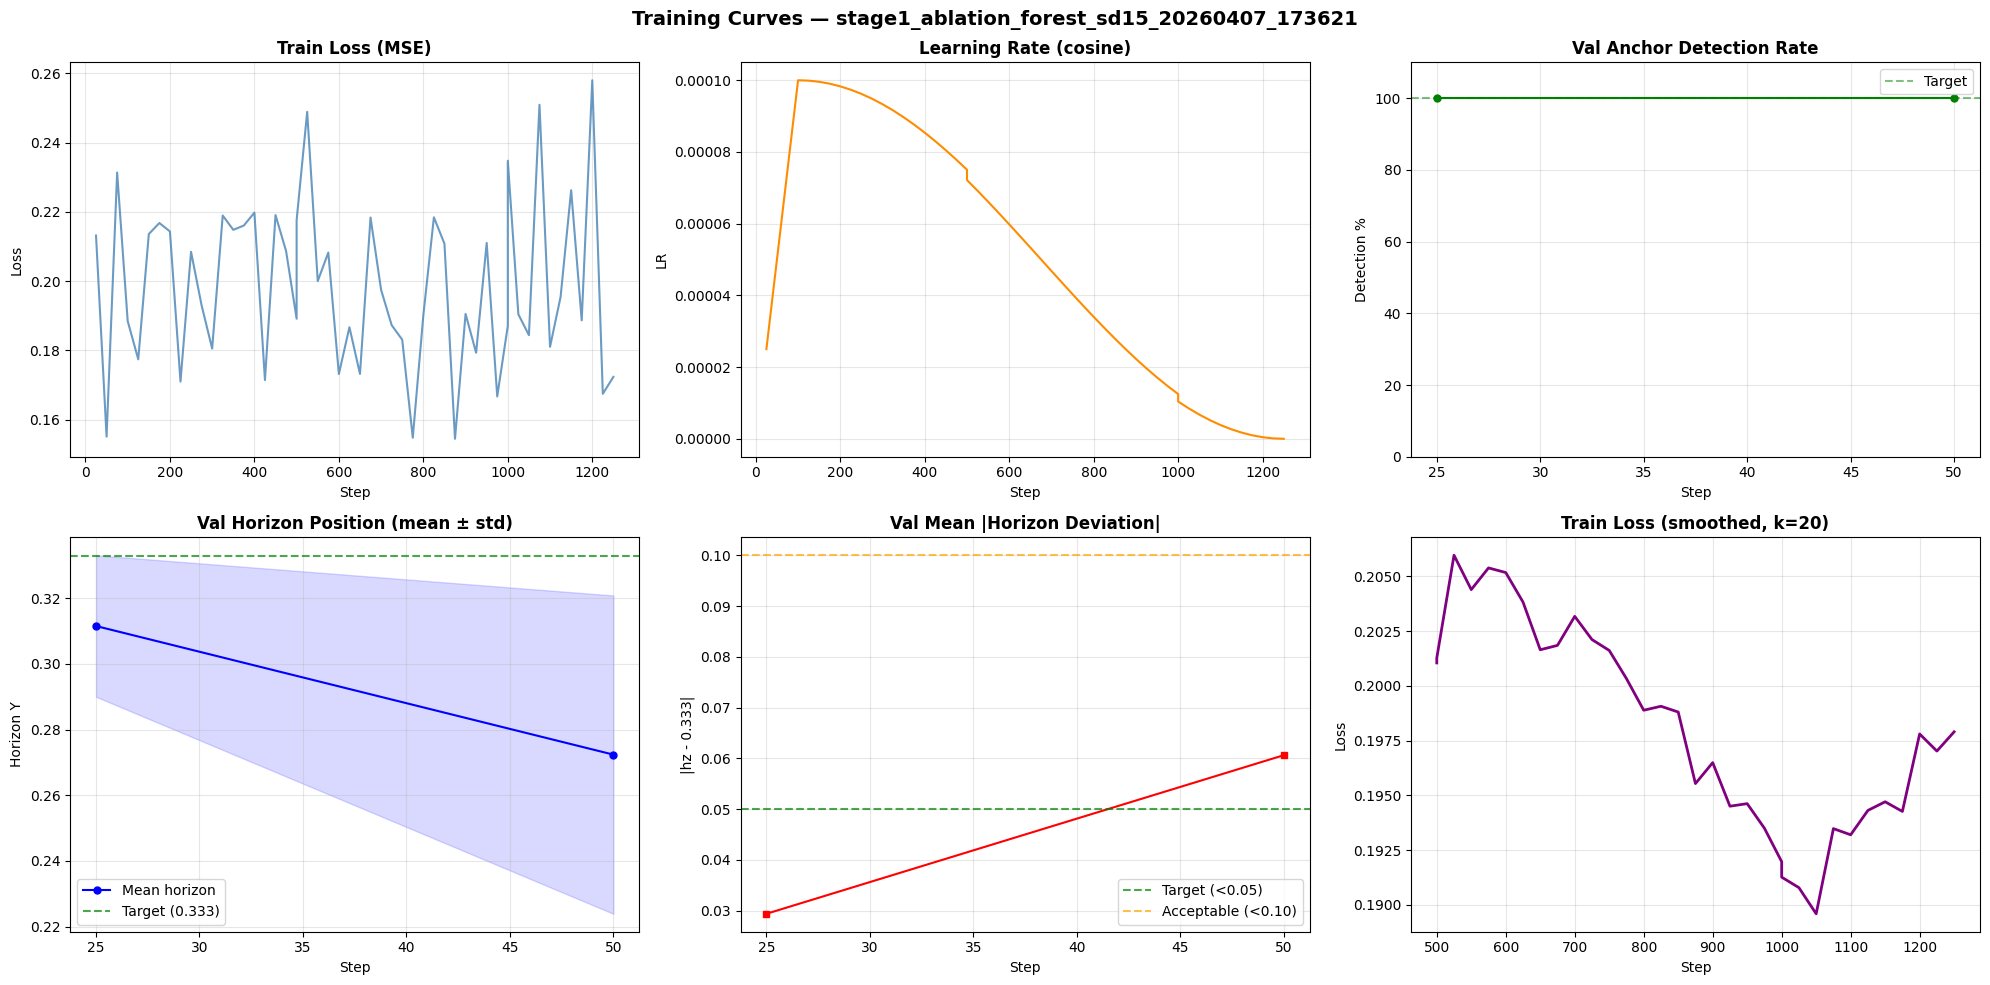

✓ Plot saved: /content/drive/MyDrive/Papers/IMAX/stage1_ablation_forest_sd15_20260407_173621/logs/training_curves.png


In [23]:
def plot_training_curves(metrics_tracker, save_path):
    d = metrics_tracker.data

    has_train = len(d['train_loss']) > 0
    has_val   = len(d['val_mean_horizon']) > 0

    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle(f"Training Curves — {RUN_NAME}", fontsize=14, fontweight='bold')

    # ── Loss ─────────────────────────────────────────────────
    ax = axes[0, 0]
    if has_train:
        steps = d['step'][:len(d['train_loss'])]
        ax.plot(steps, d['train_loss'], color='steelblue', linewidth=1.5, alpha=0.8)
        ax.set_title("Train Loss (MSE)", fontweight='bold')
        ax.set_xlabel("Step")
        ax.set_ylabel("Loss")
        ax.grid(alpha=0.3)

    # ── Learning Rate ─────────────────────────────────────────
    ax = axes[0, 1]
    if len(d['learning_rate']) > 0:
        steps = d['step'][:len(d['learning_rate'])]
        ax.plot(steps, d['learning_rate'], color='darkorange', linewidth=1.5)
        ax.set_title("Learning Rate (cosine)", fontweight='bold')
        ax.set_xlabel("Step")
        ax.set_ylabel("LR")
        ax.grid(alpha=0.3)

    # ── Val Detection Rate ────────────────────────────────────
    ax = axes[0, 2]
    if has_val:
        val_steps = [d['step'][i] for i in range(len(d['step']))
                     if i < len(d['val_detection_rate'])]
        ax.plot(d['step'][:len(d['val_detection_rate'])],
                [v*100 for v in d['val_detection_rate']],
                'go-', markersize=5, linewidth=1.5)
        ax.axhline(100, color='green', linestyle='--', alpha=0.5, label='Target')
        ax.set_title("Val Anchor Detection Rate", fontweight='bold')
        ax.set_xlabel("Step")
        ax.set_ylabel("Detection %")
        ax.set_ylim(0, 110)
        ax.legend()
        ax.grid(alpha=0.3)

    # ── Val Horizon Position ──────────────────────────────────
    ax = axes[1, 0]
    if has_val:
        ax.plot(d['step'][:len(d['val_mean_horizon'])],
                d['val_mean_horizon'], 'bo-', markersize=5, linewidth=1.5,
                label='Mean horizon')
        ax.axhline(0.333, color='green', linestyle='--', alpha=0.7, label='Target (0.333)')
        ax.fill_between(d['step'][:len(d['val_mean_horizon'])],
                        [h - s for h, s in zip(d['val_mean_horizon'], d['val_horizon_std'])],
                        [h + s for h, s in zip(d['val_mean_horizon'], d['val_horizon_std'])],
                        alpha=0.15, color='blue')
        ax.set_title("Val Horizon Position (mean ± std)", fontweight='bold')
        ax.set_xlabel("Step")
        ax.set_ylabel("Horizon Y")
        ax.legend()
        ax.grid(alpha=0.3)

    # ── Val Horizon Deviation ─────────────────────────────────
    ax = axes[1, 1]
    if has_val:
        ax.plot(d['step'][:len(d['val_horizon_dev'])],
                d['val_horizon_dev'], 'rs-', markersize=5, linewidth=1.5)
        ax.axhline(0.05, color='green', linestyle='--', alpha=0.7, label='Target (<0.05)')
        ax.axhline(0.10, color='orange', linestyle='--', alpha=0.7, label='Acceptable (<0.10)')
        ax.set_title("Val Mean |Horizon Deviation|", fontweight='bold')
        ax.set_xlabel("Step")
        ax.set_ylabel("|hz - 0.333|")
        ax.legend()
        ax.grid(alpha=0.3)

    # ── Loss (smoothed) ───────────────────────────────────────
    ax = axes[1, 2]
    if has_train and len(d['train_loss']) > 20:
        kernel = 20
        smooth = np.convolve(d['train_loss'],
                             np.ones(kernel)/kernel, mode='valid')
        steps  = d['step'][kernel-1:len(smooth)+kernel-1]
        ax.plot(steps[:len(smooth)], smooth,
                color='purple', linewidth=2)
        ax.set_title("Train Loss (smoothed, k=20)", fontweight='bold')
        ax.set_xlabel("Step")
        ax.set_ylabel("Loss")
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"✓ Plot saved: {save_path}")


plot_path = os.path.join(LOGS_DIR, "training_curves.png")
plot_training_curves(metrics_tracker, plot_path)

#testing

In [ ]:


import os, json, torch, math
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
from diffusers import UNet2DConditionModel, AutoencoderKL, DDIMScheduler
from diffusers.models.attention_processor import AttnProcessor2_0
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model
from safetensors.torch import load_file
import torch.nn as nn

# ── Config ────────────────────────────────────────────────────
# ── At the top of testing code, after finding RUN_DIR ─────────
# Load base model from saved config instead of hardcoding
with open(f"{RUN_DIR}/logs/train_config.json") as f:
    saved_config = json.load(f)

BASE_MODEL = saved_config['base_model']
VAE_MODEL  = saved_config.get('vae_model', BASE_MODEL)
print(f"✓ Base model: {BASE_MODEL}")
print(f"✓ VAE model : {VAE_MODEL}")
DEVICE      = "cuda"

# Change this per landscape
LANDSCAPE_CATEGORY = "forest"
RUN_DIR = None  # auto-find below

# Auto-find the most recent ablation run for this category
ablation_runs = sorted([
    d for d in os.listdir("/content/drive/MyDrive/Papers/IMAX")
    if f"stage1_ablation_{LANDSCAPE_CATEGORY}" in d
])
if not ablation_runs:
    raise RuntimeError(f"No ablation run found for {LANDSCAPE_CATEGORY}")
RUN_DIR     = f"/content/drive/MyDrive/Papers/IMAX/{ablation_runs[-1]}"
CKPT_DIR    = f"{RUN_DIR}/checkpoints"
OUTPUT_DIR  = f"{RUN_DIR}/test_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Using run: {ablation_runs[-1]}")

# Find all available checkpoints
available_ckpts = sorted([
    int(d.replace("checkpoint-", ""))
    for d in os.listdir(CKPT_DIR)
    if d.startswith("checkpoint-")
])
print(f"✓ Available checkpoints: {available_ckpts}")


# ============================================================
# LOAD FUNCTION
# ============================================================
def load_ablation_checkpoint(step):
    ckpt_path = os.path.join(CKPT_DIR, f"checkpoint-{step:06d}")
    print(f"\nLoading checkpoint-{step:06d}...")

    tokenizer    = CLIPTokenizer.from_pretrained(BASE_MODEL, subfolder="tokenizer")
    text_encoder = CLIPTextModel.from_pretrained(
        BASE_MODEL, subfolder="text_encoder"
    ).to(DEVICE)
    text_encoder.requires_grad_(False)

    # ── VAE: SD 1.5 uses subfolder, Realistic Vision uses separate model
    if VAE_MODEL == BASE_MODEL:
        vae = AutoencoderKL.from_pretrained(
            BASE_MODEL, subfolder="vae"
        ).to(DEVICE)
    else:
        vae = AutoencoderKL.from_pretrained(VAE_MODEL).to(DEVICE)
    vae.requires_grad_(False)

    unet_base = UNet2DConditionModel.from_pretrained(
        BASE_MODEL, subfolder="unet"
    ).to(DEVICE)
    lora_config = LoraConfig(
        r=16, lora_alpha=16,
        target_modules=["to_q", "to_k", "to_v", "to_out.0"],
        lora_dropout=0.1, bias="none",
    )
    unet = get_peft_model(unet_base, lora_config)
    lora_weights = load_file(
        os.path.join(ckpt_path, "lora_weights", "adapter_model.safetensors")
    )
    unet.load_state_dict(lora_weights, strict=False)

    inject_ip_adapter(unet, rank=8, num_tokens=1, scale=1.0)
    ip_state = torch.load(
        os.path.join(ckpt_path, "ip_adapter.pt"), map_location=DEVICE
    )
    load_ip_state_dict(unet, ip_state)

    for _, proc in unet.attn_processors.items():
        if isinstance(proc, IPAdapterAttnProcessor):
            proc.to_k_ip_down.float(); proc.to_k_ip_up.float()
            proc.to_v_ip_down.float(); proc.to_v_ip_up.float()

    anchor_proj = AnchorProjModel(
        cross_attention_dim=768, num_tokens=1
    ).to(DEVICE)
    anchor_proj.load_state_dict(
        torch.load(
            os.path.join(ckpt_path, "anchor_proj.pt"), map_location=DEVICE
        )
    )

    unet.eval()
    anchor_proj.eval()
    print(f"  ✓ Loaded checkpoint-{step:06d}")
    return tokenizer, text_encoder, vae, unet, anchor_proj

# ============================================================
# GENERATE FUNCTION (1024×536)
# ============================================================
@torch.no_grad()
def generate(
    prompt,
    tokenizer, text_encoder, vae, unet, anchor_proj,
    horizon_y       = 0.333,
    horizon_conf    = 0.9,
    saliency        = 0.3,
    fg_ratio        = 0.15,
    text_scale      = 7.5,
    anchor_scale    = 1.5,
    seed            = 42,
    num_steps       = 30,
    W               = 1024,
    H               = 536,
    negative_prompt = (
        "painting, illustration, cartoon, oil painting, watercolor, "
        "brush strokes, artistic, sketch, drawing, animated, render, CGI"
    ),
):
    # ── Scheduler loads from BASE_MODEL (auto-detected from config) ──
    scheduler = DDIMScheduler.from_pretrained(BASE_MODEL, subfolder="scheduler")
    scheduler.set_timesteps(num_steps)
    generator = torch.Generator(DEVICE).manual_seed(seed)

    def encode_text(txt):
        tok = tokenizer(
            [txt], padding="max_length",
            max_length=tokenizer.model_max_length,
            truncation=True, return_tensors="pt"
        ).to(DEVICE)
        return text_encoder(tok.input_ids)[0].to(torch.bfloat16)

    text_emb    = encode_text(prompt)
    neg_emb     = encode_text(negative_prompt)
    anchor_vec  = torch.tensor(
        [[horizon_y, horizon_conf, saliency, fg_ratio]],
        device=DEVICE, dtype=torch.float32
    )
    anchor_emb  = anchor_proj(anchor_vec).to(torch.bfloat16)
    null_anchor = torch.zeros(1, 1, 768, device=DEVICE, dtype=torch.bfloat16)

    enc_uncond = torch.cat([neg_emb,  null_anchor], dim=1)
    enc_text   = torch.cat([text_emb, null_anchor], dim=1)
    enc_full   = torch.cat([text_emb, anchor_emb],  dim=1)

    latents = torch.randn(
        1, 4, H // 8, W // 8,
        generator=generator, device=DEVICE, dtype=torch.bfloat16
    ) * scheduler.init_noise_sigma

    for t in scheduler.timesteps:
        lat_in = scheduler.scale_model_input(torch.cat([latents] * 3), t)
        with torch.amp.autocast(DEVICE, dtype=torch.bfloat16):
            noise_pred = unet(
                lat_in, t,
                encoder_hidden_states=torch.cat([enc_uncond, enc_text, enc_full])
            ).sample
        nc, nt, nf = noise_pred.chunk(3)
        latents = scheduler.step(
            nc + text_scale*(nt-nc) + anchor_scale*(nf-nt), t, latents
        ).prev_sample

    with torch.amp.autocast(DEVICE, dtype=torch.bfloat16):
        img = vae.decode(latents / vae.config.scaling_factor).sample
    img = (img / 2 + 0.5).clamp(0, 1)
    return Image.fromarray(
        (img[0].cpu().permute(1,2,0).float().numpy()*255).astype(np.uint8)
    )


def draw_horizon(ax, hz_y, H=536, color='red'):
    ax.axhline(y=int(hz_y * H), color=color, linewidth=2,
               linestyle='--', alpha=0.85)


# ============================================================
# TEST A — Checkpoint comparison (best step selection)
# Same prompt, same seed, all checkpoints
# ============================================================
print(f"\n── Test A: Checkpoint comparison [{LANDSCAPE_CATEGORY}] ──")

prompt_a = f"RAW photo, photorealistic photograph of {LANDSCAPE_CATEGORY} landscape at golden hour, DSLR, sharp focus, natural lighting, 8K"
hz_a     = 0.333
seed_a   = 42

n_ckpts  = len(available_ckpts)
fig, axes = plt.subplots(1, n_ckpts, figsize=(8 * n_ckpts, 7))
if n_ckpts == 1:
    axes = [axes]
fig.suptitle(
    f'Test A — Checkpoint Comparison [{LANDSCAPE_CATEGORY.upper()}]\n'
    f'"{prompt_a[:70]}..."  target hz={hz_a}',
    fontsize=12, fontweight='bold'
)

# Load validation metrics to show on plot
metrics_path = f"{RUN_DIR}/logs/training_metrics.json"
val_devs     = {}
if os.path.exists(metrics_path):
    with open(metrics_path) as f:
        mdata = json.load(f)
    for i, step in enumerate(mdata.get('step', [])):
        if i < len(mdata.get('val_horizon_dev', [])):
            val_devs[step] = mdata['val_horizon_dev'][i]

ckpt_images = []
for ax, step in zip(axes, available_ckpts):
    tok_, te_, vae_, unet_, ap_ = load_ablation_checkpoint(step)
    img = generate(prompt_a, tok_, te_, vae_, unet_, ap_,
                   horizon_y=hz_a, seed=seed_a)
    ckpt_images.append((step, img))
    ax.imshow(img)
    draw_horizon(ax, hz_a)
    dev_str = f"  val_dev={val_devs[step]:.3f}" if step in val_devs else ""
    ax.set_title(f"Step {step}{dev_str}", fontsize=10, fontweight='bold')
    ax.axis('off')
    del unet_, ap_, te_, vae_
    torch.cuda.empty_cache()

plt.tight_layout()
path = f"{OUTPUT_DIR}/testA_checkpoint_comparison.png"
plt.savefig(path, dpi=120, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved: {path}")

# Replace the best checkpoint selection block with this:
if val_devs:
    # Convert all keys to int for comparison
    val_devs_int = {int(k): v for k, v in val_devs.items()}
    valid_steps  = [s for s in available_ckpts if s in val_devs_int]
    if valid_steps:
        best_step = min(valid_steps, key=lambda s: val_devs_int[s])
        print(f"\n  Best checkpoint: step {best_step} "
              f"(val_dev={val_devs_int[best_step]:.3f})")
    else:
        best_step = available_ckpts[0]
        print(f"\n  No matching val metrics, using first checkpoint: {best_step}")
else:
    best_step = available_ckpts[0]
    print(f"\n  No val metrics found, using first checkpoint: {best_step}")
# Load best for remaining tests
print(f"\nLoading best checkpoint (step {best_step}) for tests B-D...")
tokenizer, text_encoder, vae, unet, anchor_proj = load_ablation_checkpoint(best_step)


# ============================================================
# TEST B — Horizon control sweep
# ============================================================
print(f"\n── Test B: Horizon sweep [{LANDSCAPE_CATEGORY}] ──")

hz_values = [0.15, 0.25, 0.333, 0.45, 0.60]
hz_labels = ["Very High\nhz=0.15", "High\nhz=0.25", "Rule of Thirds\nhz=0.333",
             "Low\nhz=0.45", "Very Low\nhz=0.60"]

images_b = []
for hz in hz_values:
    print(f"  hz={hz:.3f}...")
    img = generate(prompt_a, tokenizer, text_encoder, vae, unet, anchor_proj,
                   horizon_y=hz, seed=42)
    images_b.append(img)

fig, axes = plt.subplots(1, 5, figsize=(32, 7))
fig.suptitle(
    f'Test B — Horizon Control [{LANDSCAPE_CATEGORY.upper()}]  '
    f'(step {best_step})\n"{prompt_a[:70]}..."',
    fontsize=11, fontweight='bold'
)
for ax, img, label, hz in zip(axes, images_b, hz_labels, hz_values):
    ax.imshow(img)
    draw_horizon(ax, hz)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
path = f"{OUTPUT_DIR}/testB_horizon_sweep.png"
plt.savefig(path, dpi=120, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved: {path}")


# ============================================================
# TEST C — Anchor scale sweep
# ============================================================
print(f"\n── Test C: Anchor scale sweep [{LANDSCAPE_CATEGORY}] ──")

anchor_scales = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
images_c = []
for scale in anchor_scales:
    print(f"  anchor_scale={scale}...")
    img = generate(prompt_a, tokenizer, text_encoder, vae, unet, anchor_proj,
                   horizon_y=0.15, anchor_scale=scale, seed=42)
    images_c.append(img)

fig, axes = plt.subplots(1, 6, figsize=(38, 7))
fig.suptitle(
    f'Test C — Anchor Scale Sweep [{LANDSCAPE_CATEGORY.upper()}]  '
    f'(target hz=0.15, step {best_step})\n'
    f'scale=0 → no anchor influence',
    fontsize=11, fontweight='bold'
)
for ax, img, scale in zip(axes, images_c, anchor_scales):
    ax.imshow(img)
    draw_horizon(ax, 0.15, color='lime')
    ax.set_title(f"scale={scale}", fontsize=10, fontweight='bold',
                 color='green' if scale == 1.5 else 'black')
    ax.axis('off')
plt.tight_layout()
path = f"{OUTPUT_DIR}/testC_anchor_scale.png"
plt.savefig(path, dpi=120, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved: {path}")


# ============================================================
# TEST D — 4 prompts × 3 horizons
# ============================================================
print(f"\n── Test D: Prompt variety [{LANDSCAPE_CATEGORY}] ──")

prompts_d = [
    f"RAW photo, photorealistic photograph of {LANDSCAPE_CATEGORY} landscape at golden hour, DSLR, 8K",
    f"RAW photo, photorealistic photograph of dramatic {LANDSCAPE_CATEGORY} scenery at sunset, DSLR, 8K",
    f"RAW photo, photorealistic photograph of {LANDSCAPE_CATEGORY} at sunrise, wide angle, DSLR, 8K",
    f"RAW photo, photorealistic photograph of cinematic {LANDSCAPE_CATEGORY} with dramatic sky, DSLR, 8K",
]
hz_d = [0.20, 0.333, 0.55]

fig, axes = plt.subplots(4, 3, figsize=(24, 28))
fig.suptitle(
    f'Test D — Prompt Variety × Horizon [{LANDSCAPE_CATEGORY.upper()}]  '
    f'(step {best_step})',
    fontsize=13, fontweight='bold'
)
for row, prompt in enumerate(prompts_d):
    for col, hz in enumerate(hz_d):
        print(f"  [{row},{col}] hz={hz}...")
        img = generate(prompt, tokenizer, text_encoder, vae, unet, anchor_proj,
                       horizon_y=hz, seed=42)
        ax  = axes[row, col]
        ax.imshow(img)
        draw_horizon(ax, hz)
        ax.set_title(
            f"hz={hz} | {prompt[40:65]}...",
            fontsize=9, fontweight='bold'
        )
        ax.axis('off')

plt.tight_layout()
path = f"{OUTPUT_DIR}/testD_prompt_variety.png"
plt.savefig(path, dpi=110, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved: {path}")


# ============================================================
# TEST E — Training curve
# ============================================================
print(f"\n── Test E: Training curve [{LANDSCAPE_CATEGORY}] ──")

if os.path.exists(metrics_path):
    with open(metrics_path) as f:
        mdata = json.load(f)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(
        f'Training Curves [{LANDSCAPE_CATEGORY.upper()}]',
        fontsize=13, fontweight='bold'
    )

    # Loss
    if mdata.get('train_loss'):
        steps = mdata['step'][:len(mdata['train_loss'])]
        axes[0].plot(steps, mdata['train_loss'], color='steelblue', linewidth=1.5)
        axes[0].set_title("Train Loss", fontweight='bold')
        axes[0].set_xlabel("Step")
        axes[0].grid(alpha=0.3)

    # Horizon deviation
    if mdata.get('val_horizon_dev'):
        val_steps = mdata['step'][:len(mdata['val_horizon_dev'])]
        axes[1].plot(val_steps, mdata['val_horizon_dev'],
                     'rs-', markersize=6, linewidth=1.5)
        axes[1].axhline(0.05, color='green', linestyle='--',
                        alpha=0.7, label='Target <0.05')
        axes[1].axhline(y=mdata['val_horizon_dev'][
                            mdata['val_horizon_dev'].index(
                                min(mdata['val_horizon_dev']))],
                        color='orange', linestyle=':', alpha=0.7,
                        label=f'Best={min(mdata["val_horizon_dev"]):.3f}')
        axes[1].set_title("Val Horizon Deviation", fontweight='bold')
        axes[1].set_xlabel("Step")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

    # Detection rate
    if mdata.get('val_detection_rate'):
        val_steps = mdata['step'][:len(mdata['val_detection_rate'])]
        axes[2].plot(val_steps,
                     [v*100 for v in mdata['val_detection_rate']],
                     'go-', markersize=6, linewidth=1.5)
        axes[2].axhline(100, color='green', linestyle='--',
                        alpha=0.5, label='Target 100%')
        axes[2].set_title("Val Detection Rate", fontweight='bold')
        axes[2].set_xlabel("Step")
        axes[2].set_ylim(0, 110)
        axes[2].legend()
        axes[2].grid(alpha=0.3)

    plt.tight_layout()
    path = f"{OUTPUT_DIR}/testE_training_curves.png"
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"  ✓ Saved: {path}")
else:
    print("  ⚠ No metrics file found")


print("\n" + "="*60)
print(f"  ALL TESTS COMPLETE [{LANDSCAPE_CATEGORY.upper()}]")
print(f"  Best checkpoint : step {best_step}")
print(f"  Outputs saved to: {OUTPUT_DIR}")
print("="*60)

Output hidden; open in https://colab.research.google.com to view.